# Stage 3 Results Viewer (READ-ONLY)

Отдельный ноутбук для просмотра результатов test evaluation без риска запустить бандиты или перезаписать данные.

Не запускает бандитов, ничего не пишет на диск, не трогает `stage3_test_evaluation.ipynb`. Безопасно перезапускать.

## 1. Настройка пути

- `stage3_test_eval_20260523_112204/` — decision_only
- `stage3_test_eval_20260525_044134/` — all_bars / raw_action (ablation)

In [23]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', lambda x: f'{x:.4f}' if abs(x) < 1000 else f'{x:.2f}')

EVAL_BASE = Path('final_test_evaluation_outputs')
EVAL_DIR = EVAL_BASE / 'stage3_test_eval_20260525_044134'
EVAL_DIR_COMPARE = EVAL_BASE / 'stage3_test_eval_20260523_112204'

assert EVAL_DIR.exists(), f'Не существует: {EVAL_DIR}'
print(f'Главная папка:    {EVAL_DIR.name}')
if EVAL_DIR_COMPARE and EVAL_DIR_COMPARE.exists():
    print(f'Сравнение с:      {EVAL_DIR_COMPARE.name}')
else:
    EVAL_DIR_COMPARE = None

Главная папка:    stage3_test_eval_20260525_044134
Сравнение с:      stage3_test_eval_20260523_112204


## 2. Метаданные прогона

In [24]:
def detect_run_meta(eval_dir: Path) -> dict:
    cfgs = pd.read_csv(eval_dir / 'final_test_configurations.csv')
    opt = cfgs[cfgs['config_type'] == 'optimized'].iloc[0]
    params = json.loads(opt['bandit_params_json'])
    return {'folder': eval_dir.name,
            'n_optimized': int((cfgs['config_type']=='optimized').sum()),
            'n_default':   int((cfgs['config_type']=='screening_default').sum()),
            'algorithms':  sorted(cfgs['algorithm'].unique().tolist()),
            'reward_clip': params.get('reward_clip')}

meta = detect_run_meta(EVAL_DIR)
print('=== Главный прогон ===')
for k, v in meta.items(): print(f'  {k}: {v}')
if EVAL_DIR_COMPARE:
    print()
    print('=== Сравнение ===')
    for k, v in detect_run_meta(EVAL_DIR_COMPARE).items(): print(f'  {k}: {v}')

=== Главный прогон ===
  folder: stage3_test_eval_20260525_044134
  n_optimized: 8
  n_default: 8
  algorithms: ['discounted_lints', 'discounted_linucb', 'sw_lints', 'sw_linucb']
  reward_clip: 0.1

=== Сравнение ===
  folder: stage3_test_eval_20260523_112204
  n_optimized: 8
  n_default: 8
  algorithms: ['discounted_lints', 'discounted_linucb', 'sw_lints', 'sw_linucb']
  reward_clip: 0.1


## 3. Ranking оптимизированных конфигураций

In [25]:
def make_ranking_table(eval_dir: Path) -> pd.DataFrame:
    df = pd.read_csv(eval_dir / 'test_optimized_config_ranking.csv')
    cols = ['algorithm','method_group','test_dro','test_return_pct',
            'test_median_symbol_return_pct','median_max_drawdown_abs',
            'median_profit_factor','median_total_trades']
    cols = [c for c in cols if c in df.columns]
    df = df[cols].sort_values('test_dro', ascending=False).reset_index(drop=True)
    df.index = df.index + 1
    return df.round(3)

display(Markdown(f'### `{EVAL_DIR.name}`'))
display(make_ranking_table(EVAL_DIR))
if EVAL_DIR_COMPARE:
    display(Markdown(f'### `{EVAL_DIR_COMPARE.name}`'))
    display(make_ranking_table(EVAL_DIR_COMPARE))

### `stage3_test_eval_20260525_044134`

,algorithm,method_group,test_dro,test_return_pct,test_median_symbol_return_pct,median_max_drawdown_abs,median_profit_factor,median_total_trades
1,sw_linucb,hybrid,-3.3140,-6.0100,-8.1530,9.0970,0.5470,285.0000
2,sw_lints,hybrid,-4.0150,-7.2780,-7.5300,9.1610,0.5150,274.0000
3,discounted_lints,hybrid,-4.1880,-6.9480,-6.9100,8.7200,0.5740,385.0000
4,discounted_linucb,hybrid,-4.8050,-8.1680,-8.4830,9.5580,0.4950,424.0000
5,discounted_lints,corr,-5.0550,-7.6070,-8.3900,9.5470,0.6330,488.5000
6,discounted_linucb,corr,-5.0780,-7.7380,-9.0750,9.5410,0.6550,499.0000
7,sw_linucb,corr,-5.3490,-10.0290,-10.1900,10.9720,0.4910,413.0000
8,sw_lints,corr,-6.7690,-10.6780,-9.4060,11.6330,0.5100,507.5000


### `stage3_test_eval_20260523_112204`

,algorithm,method_group,test_dro,test_return_pct,test_median_symbol_return_pct,median_max_drawdown_abs,median_profit_factor,median_total_trades
1,sw_lints,hybrid,-3.5900,-6.4520,-6.6290,8.2280,0.5590,270.0000
2,discounted_linucb,corr,-4.2750,-8.2870,-9.4490,11.7190,0.5900,557.0000
3,discounted_linucb,hybrid,-4.4720,-7.4840,-7.7850,9.4800,0.5990,432.0000
4,sw_linucb,hybrid,-4.6230,-8.7630,-8.4160,9.5610,0.5770,392.0000
5,discounted_lints,hybrid,-4.6250,-7.7580,-8.2450,9.2150,0.5580,407.5000
6,sw_linucb,corr,-5.1440,-8.1870,-7.7050,9.0370,0.5440,526.0000
7,sw_lints,corr,-5.2280,-8.1070,-8.0900,9.7450,0.5410,452.0000
8,discounted_lints,corr,-5.5330,-9.6360,-9.0890,11.2520,0.5890,550.5000


## 4. Hybrid vs Corr (главное сравнение)

In [26]:
def make_hybrid_vs_corr(eval_dir: Path) -> pd.DataFrame:
    df = pd.read_csv(eval_dir / 'test_corr_vs_hybrid_by_algorithm.csv')
    cols = ['algorithm','corr_test_dro','hybrid_test_dro','hybrid_minus_corr_dro',
            'corr_test_return','hybrid_test_return','hybrid_minus_corr_return',
            'corr_drawdown','hybrid_drawdown','corr_trades','hybrid_trades']
    return df[[c for c in cols if c in df.columns]].round(3)

display(Markdown(f'### `{EVAL_DIR.name}`'))
display(make_hybrid_vs_corr(EVAL_DIR))
if EVAL_DIR_COMPARE:
    display(Markdown(f'### `{EVAL_DIR_COMPARE.name}`'))
    display(make_hybrid_vs_corr(EVAL_DIR_COMPARE))

### `stage3_test_eval_20260525_044134`

,algorithm,corr_test_dro,hybrid_test_dro,hybrid_minus_corr_dro,corr_test_return,hybrid_test_return,hybrid_minus_corr_return,corr_drawdown,hybrid_drawdown,corr_trades,hybrid_trades
0,discounted_lints,-5.0550,-4.1880,0.8670,-7.6070,-6.9480,0.6600,9.5470,8.7200,488.5000,385.0000
1,discounted_linucb,-5.0780,-4.8050,0.2730,-7.7380,-8.1680,-0.4300,9.5410,9.5580,499.0000,424.0000
2,sw_lints,-6.7690,-4.0150,2.7540,-10.6780,-7.2780,3.4000,11.6330,9.1610,507.5000,274.0000
3,sw_linucb,-5.3490,-3.3140,2.0340,-10.0290,-6.0100,4.0190,10.9720,9.0970,413.0000,285.0000


### `stage3_test_eval_20260523_112204`

,algorithm,corr_test_dro,hybrid_test_dro,hybrid_minus_corr_dro,corr_test_return,hybrid_test_return,hybrid_minus_corr_return,corr_drawdown,hybrid_drawdown,corr_trades,hybrid_trades
0,discounted_lints,-5.5330,-4.6250,0.9080,-9.6360,-7.7580,1.8780,11.2520,9.2150,550.5000,407.5000
1,discounted_linucb,-4.2750,-4.4720,-0.1970,-8.2870,-7.4840,0.8030,11.7190,9.4800,557.0000,432.0000
2,sw_lints,-5.2280,-3.5900,1.6380,-8.1070,-6.4520,1.6550,9.7450,8.2280,452.0000,270.0000
3,sw_linucb,-5.1440,-4.6230,0.5200,-8.1870,-8.7630,-0.5760,9.0370,9.5610,526.0000,392.0000


In [27]:
def make_bootstrap_ci(eval_dir: Path) -> pd.DataFrame:
    p = eval_dir / 'test_bootstrap_hybrid_minus_corr_ci.csv'
    return pd.read_csv(p).round(3) if p.exists() else pd.DataFrame()

display(Markdown(f'### Bootstrap CI (Δ = hybrid - corr) — `{EVAL_DIR.name}`'))
display(make_bootstrap_ci(EVAL_DIR))
if EVAL_DIR_COMPARE:
    display(Markdown(f'### Bootstrap CI — `{EVAL_DIR_COMPARE.name}`'))
    display(make_bootstrap_ci(EVAL_DIR_COMPARE))

### Bootstrap CI (Δ = hybrid - corr) — `stage3_test_eval_20260525_044134`

,algorithm,delta_mean,ci_lo_95,ci_hi_95,p_value_hybrid_better,n_pairs
0,discounted_lints,0.8240,0.5590,1.0870,0.0000,30
1,sw_lints,2.9400,2.5840,3.2440,0.0000,30


### Bootstrap CI — `stage3_test_eval_20260523_112204`

,algorithm,delta_mean,ci_lo_95,ci_hi_95,p_value_hybrid_better,n_pairs
0,discounted_lints,0.6760,0.3050,1.0160,0.0010,30
1,sw_lints,1.7260,1.3800,2.0260,0.0000,30


## 5. Сравнение update-режимов одной таблицей

In [28]:
if EVAL_DIR_COMPARE:
    a = make_hybrid_vs_corr(EVAL_DIR).set_index('algorithm')
    b = make_hybrid_vs_corr(EVAL_DIR_COMPARE).set_index('algorithm')
    main_label = 'all_bars' if 'all_bars' in EVAL_DIR.name.lower() else EVAL_DIR.name[-8:]
    cmp_label  = 'decision_only' if 'decision' in EVAL_DIR_COMPARE.name.lower() else EVAL_DIR_COMPARE.name[-8:]
    join = pd.DataFrame(index=a.index)
    join[f'corr ({cmp_label})']    = b['corr_test_dro']
    join[f'corr ({main_label})']   = a['corr_test_dro']
    join[f'hybrid ({cmp_label})']  = b['hybrid_test_dro']
    join[f'hybrid ({main_label})'] = a['hybrid_test_dro']
    join[f'Δ ({cmp_label})']       = b['hybrid_minus_corr_dro']
    join[f'Δ ({main_label})']      = a['hybrid_minus_corr_dro']
    display(Markdown('### DRO: corr vs hybrid в двух update-режимах'))
    display(join.round(3))
else:
    print('Сравнение отключено')

### DRO: corr vs hybrid в двух update-режимах

,corr (3_112204),corr (5_044134),hybrid (3_112204),hybrid (5_044134),Δ (3_112204),Δ (5_044134)
algorithm,,,,,,
discounted_lints,-5.5330,-5.0550,-4.6250,-4.1880,0.9080,0.8670
discounted_linucb,-4.2750,-5.0780,-4.4720,-4.8050,-0.1970,0.2730
sw_lints,-5.2280,-6.7690,-3.5900,-4.0150,1.6380,2.7540
sw_linucb,-5.1440,-5.3490,-4.6230,-3.3140,0.5200,2.0340


## 6. Per-symbol breakdown для hybrid

In [29]:
def per_symbol_for_hybrid(eval_dir: Path) -> pd.DataFrame:
    df = pd.read_csv(eval_dir / 'test_per_symbol_metrics_optimized.csv')
    df = df[df['method_group']=='hybrid']
    p = df.pivot_table(index='algorithm', columns='symbol', values='median_return_pct').round(2)
    p['mean'] = p.mean(axis=1).round(2)
    return p

display(Markdown(f'### Hybrid возврат по символам, % — `{EVAL_DIR.name}`'))
display(per_symbol_for_hybrid(EVAL_DIR))
if EVAL_DIR_COMPARE:
    display(Markdown(f'### Hybrid возврат по символам, % — `{EVAL_DIR_COMPARE.name}`'))
    display(per_symbol_for_hybrid(EVAL_DIR_COMPARE))

### Hybrid возврат по символам, % — `stage3_test_eval_20260525_044134`

symbol,BTCUSDT,ETHUSDT,SOLUSDT,mean
algorithm,,,,
discounted_lints,-8.7300,-6.6500,-5.1900,-6.8600
discounted_linucb,-8.4800,-10.4400,-5.5800,-8.1700
sw_lints,-5.9000,-8.2800,-8.2300,-7.4700
sw_linucb,-8.1500,-1.5500,-8.3200,-6.0100


### Hybrid возврат по символам, % — `stage3_test_eval_20260523_112204`

symbol,BTCUSDT,ETHUSDT,SOLUSDT,mean
algorithm,,,,
discounted_lints,-9.6900,-6.8900,-5.9900,-7.5200
discounted_linucb,-8.2700,-6.4000,-7.7800,-7.4800
sw_lints,-7.4000,-5.3600,-6.7400,-6.5000
sw_linucb,-8.1600,-8.4200,-9.7200,-8.7700


## 7. Feature attribution: использует ли бандит HIE?

`share_hie_market` — доля edge-вклада на HIE-фичи. Baseline = 0.5.

In [30]:
def attribution_summary(eval_dir: Path) -> pd.DataFrame:
    p = eval_dir / 'feature_attribution_share_summary.csv'
    if not p.exists(): return pd.DataFrame()
    df = pd.read_csv(p)
    keep = ['algorithm','method_group','n_obs','share_hie_market_median',
            'ci95_lo','ci95_hi','p_value_share_above_0_5']
    return df[[c for c in keep if c in df.columns]].round(4)

display(Markdown(f'### `{EVAL_DIR.name}`'))
display(attribution_summary(EVAL_DIR))
if EVAL_DIR_COMPARE:
    display(Markdown(f'### `{EVAL_DIR_COMPARE.name}`'))
    display(attribution_summary(EVAL_DIR_COMPARE))

### `stage3_test_eval_20260525_044134`

,algorithm,method_group,n_obs,share_hie_market_median,ci95_lo,ci95_hi,p_value_share_above_0_5
0,sw_lints,hybrid,90,0.6641,0.6560,0.6702,0.0000
1,sw_linucb,hybrid,3,0.6569,0.6289,0.6618,0.0000
2,discounted_lints,hybrid,90,0.5737,0.5510,0.6071,0.0000
3,discounted_linucb,hybrid,3,0.5034,0.4226,0.5911,0.2570


### `stage3_test_eval_20260523_112204`

,algorithm,method_group,n_obs,share_hie_market_median,ci95_lo,ci95_hi,p_value_share_above_0_5
0,sw_lints,hybrid,90,0.6486,0.6433,0.6659,0.0000
1,sw_linucb,hybrid,3,0.5895,0.5841,0.6741,0.0000
2,discounted_lints,hybrid,90,0.5853,0.5422,0.6105,0.0000
3,discounted_linucb,hybrid,3,0.5085,0.4724,0.7143,0.2570


In [31]:
def top_features_by_algo(eval_dir: Path, top_n: int = 6) -> pd.DataFrame:
    p = eval_dir / 'feature_attribution_topk_summary.csv'
    if not p.exists(): return pd.DataFrame()
    df = pd.read_csv(p)
    out = []
    for alg in sorted(df['algorithm'].unique()):
        sub = df[df['algorithm']==alg].sort_values('mean_sum_abs_contribution', ascending=False).head(top_n)
        for _, r in sub.iterrows():
            out.append({'algorithm': alg, 'feature': r['feature_name'],
                        'origin': r['feature_origin'],
                        'top3_freq': round(r['top3_frequency'], 2),
                        'mean_rank': round(r['mean_rank'], 2),
                        'mean_contrib': round(r['mean_sum_abs_contribution'], 1)})
    return pd.DataFrame(out)

display(Markdown(f'### Top-фичи по hybrid configs — `{EVAL_DIR.name}`'))
display(top_features_by_algo(EVAL_DIR))

### Top-фичи по hybrid configs — `stage3_test_eval_20260525_044134`

,algorithm,feature,origin,top3_freq,mean_rank,mean_contrib
0,discounted_lints,dist_to_high_168_sqrt_z,hie,0.4700,4.1600,24.8000
1,discounted_lints,ema_spread_50_100_z,hie,0.4600,4.0900,21.2000
2,discounted_lints,ema_spread_9_21_z,corr,0.7700,3.1600,21.0000
3,discounted_lints,ADX_72_scaled,hie,0.3300,4.6000,20.5000
4,discounted_lints,ema_spread_100_200_z,hie,0.5600,4.3900,19.8000
5,discounted_lints,vol_ratio_72_log1p_z,corr,0.2100,6.2800,15.3000
6,discounted_linucb,dist_to_high_168_sqrt_z,hie,0.3300,3.6700,23.1000
7,discounted_linucb,vol_ratio_72_log1p_z,corr,0.3300,5.3300,21.2000
8,discounted_linucb,ADX_72_scaled,hie,0.6700,5.0000,18.3000
9,discounted_linucb,MOM_pct_14_z,corr,0.0000,4.3300,16.7000


## 8. Equity curves: hybrid vs corr per-algorithm

Четыре subplot'а — по одному на алгоритм. **Confidence bands:** IQR 25-75 перцентилей по 30 seeds для TS (lints). Для UCB (linucb, 1 seed) — только линия.

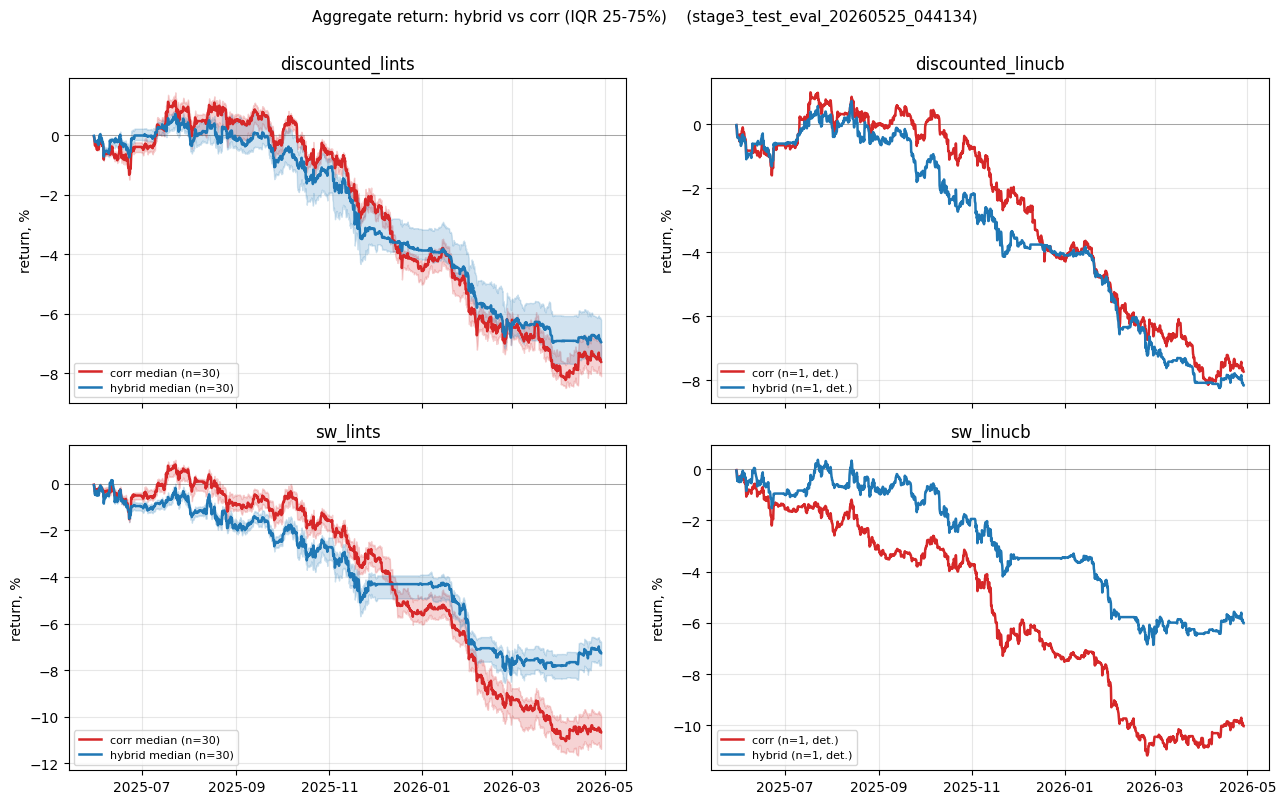

In [32]:
CI_LO, CI_HI = 0.25, 0.75

def _curves(eq: pd.DataFrame, mask):
    sub = eq[mask]
    if sub.empty: return None, None, None, 0
    g = sub.groupby('timestamp')['aggregate_return_pct']
    return g.median(), g.quantile(CI_LO), g.quantile(CI_HI), sub['seed'].nunique()

def plot_hybrid_vs_corr_equity(eval_dir: Path, title_suffix: str = ''):
    eq = pd.read_csv(eval_dir / 'diagnostics' / 'test_aggregate_equity_curves.csv', parse_dates=['timestamp'])
    eq_opt = eq[eq['config_type'] == 'optimized'].copy()
    algos = sorted(eq_opt['algorithm'].unique())
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
    for ax, alg in zip(axes.flat, algos):
        for mg, color in [('corr','#d62728'), ('hybrid','#1f77b4')]:
            mask = (eq_opt['algorithm']==alg) & (eq_opt['method_group']==mg)
            med, lo, hi, n = _curves(eq_opt, mask)
            if med is None: continue
            if n > 1:
                ax.fill_between(med.index, lo.values, hi.values, color=color, alpha=0.20, zorder=2)
                ax.plot(med.index, med.values, color=color, lw=1.8, zorder=3, label=f'{mg} median (n={n})')
            else:
                ax.plot(med.index, med.values, color=color, lw=1.8, zorder=3, label=f'{mg} (n=1, det.)')
        ax.axhline(0, color='black', lw=0.5, alpha=0.4)
        ax.set_title(alg); ax.set_ylabel('return, %'); ax.grid(alpha=0.3)
        ax.legend(loc='lower left', fontsize=8)
    plt.suptitle(f'Aggregate return: hybrid vs corr (IQR 25-75%)  {title_suffix}', fontsize=11, y=1.00)
    plt.tight_layout(); plt.show()

plot_hybrid_vs_corr_equity(EVAL_DIR, f'  ({EVAL_DIR.name})')

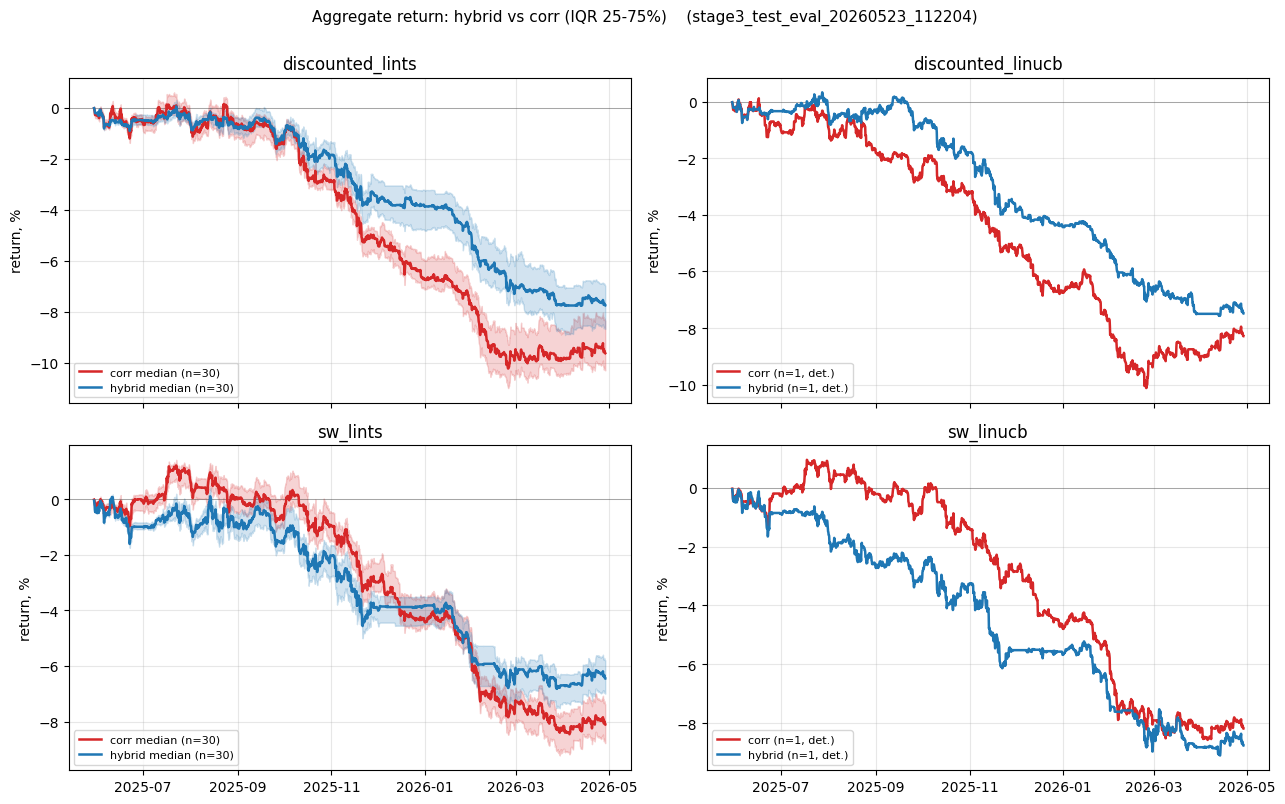

In [33]:
if EVAL_DIR_COMPARE:
    plot_hybrid_vs_corr_equity(EVAL_DIR_COMPARE, f'  ({EVAL_DIR_COMPARE.name})')

## 9. Сводный график: best corr vs best hybrid + baselines

На одном графике 4 линии:
- **best corr** — оптимизированная corr-конфигурация с лучшим test DRO
- **best hybrid** — оптимизированная hybrid-конфигурация с лучшим test DRO
- **buy & hold (10%)** — пассивный baseline на тех же 10% капитала
- **random** — случайный выбор действия (30 seeds → IQR band)

Best configs (test_dro):
  corr    : discounted_lints   (test_dro=-5.055)
  hybrid  : sw_linucb   (test_dro=-3.314)


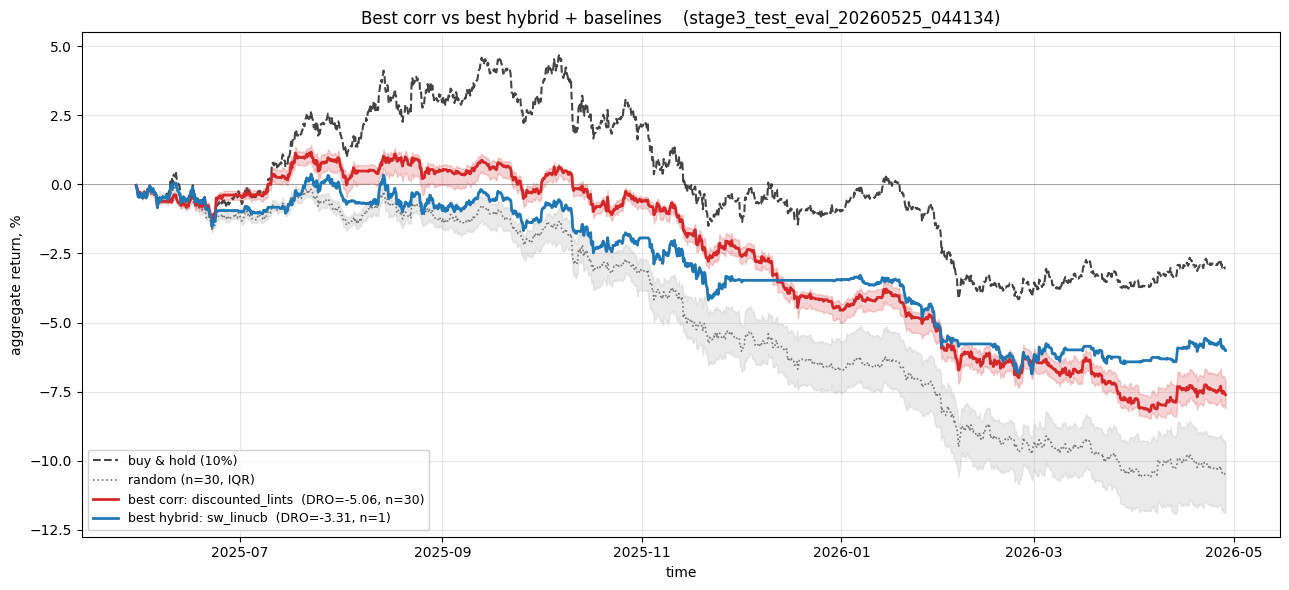

In [34]:
BASELINE_BUY_HOLD = 'baseline__buy_hold_entry_cost_position_size'
BASELINE_RANDOM   = 'baseline__random_policy'

def find_best_per_method(eval_dir: Path) -> dict:
    r = pd.read_csv(eval_dir / 'test_optimized_config_ranking.csv')
    best = {}
    for mg in ['corr','hybrid']:
        sub = r[r['method_group']==mg].sort_values('test_dro', ascending=False).head(1)
        if not sub.empty:
            best[mg] = (sub.iloc[0]['algorithm'], float(sub.iloc[0]['test_dro']))
    return best

def plot_best_vs_best(eval_dir: Path, title_suffix: str = ''):
    eq = pd.read_csv(eval_dir / 'diagnostics' / 'test_aggregate_equity_curves.csv', parse_dates=['timestamp'])
    best = find_best_per_method(eval_dir)
    print('Best configs (test_dro):')
    for mg, (alg, dro) in best.items():
        print(f'  {mg:8s}: {alg}   (test_dro={dro:+.3f})')

    bh_med, _, _, _ = _curves(eq, eq['config_id'] == BASELINE_BUY_HOLD)
    rnd_med, rnd_lo, rnd_hi, rnd_n = _curves(eq, eq['config_id'] == BASELINE_RANDOM)
    eq_opt = eq[eq['config_type']=='optimized'].copy()

    fig, ax = plt.subplots(figsize=(13, 6))
    if bh_med is not None:
        ax.plot(bh_med.index, bh_med.values, label='buy & hold (10%)', color='#444444', lw=1.5, linestyle='--', zorder=2)
    if rnd_med is not None:
        ax.fill_between(rnd_med.index, rnd_lo.values, rnd_hi.values, color='#bbbbbb', alpha=0.30, zorder=1)
        ax.plot(rnd_med.index, rnd_med.values, label=f'random (n={rnd_n}, IQR)', color='#777777', lw=1.2, linestyle=':', zorder=2)

    for mg, color in [('corr','#d62728'), ('hybrid','#1f77b4')]:
        if mg not in best: continue
        alg, dro = best[mg]
        mask = (eq_opt['algorithm']==alg) & (eq_opt['method_group']==mg)
        med, lo, hi, n = _curves(eq_opt, mask)
        if med is None: continue
        label = f'best {mg}: {alg}  (DRO={dro:+.2f}, n={n})'
        if n > 1:
            ax.fill_between(med.index, lo.values, hi.values, color=color, alpha=0.20, zorder=3)
        ax.plot(med.index, med.values, color=color, lw=2.0, zorder=4, label=label)

    ax.axhline(0, color='black', lw=0.5, alpha=0.4)
    ax.set_xlabel('time'); ax.set_ylabel('aggregate return, %')
    ax.set_title(f'Best corr vs best hybrid + baselines  {title_suffix}', fontsize=12)
    ax.grid(alpha=0.3); ax.legend(loc='lower left', fontsize=9, framealpha=0.9)
    plt.tight_layout(); plt.show()

plot_best_vs_best(EVAL_DIR, f'  ({EVAL_DIR.name})')

Best configs (test_dro):
  corr    : discounted_linucb   (test_dro=-4.275)
  hybrid  : sw_lints   (test_dro=-3.590)


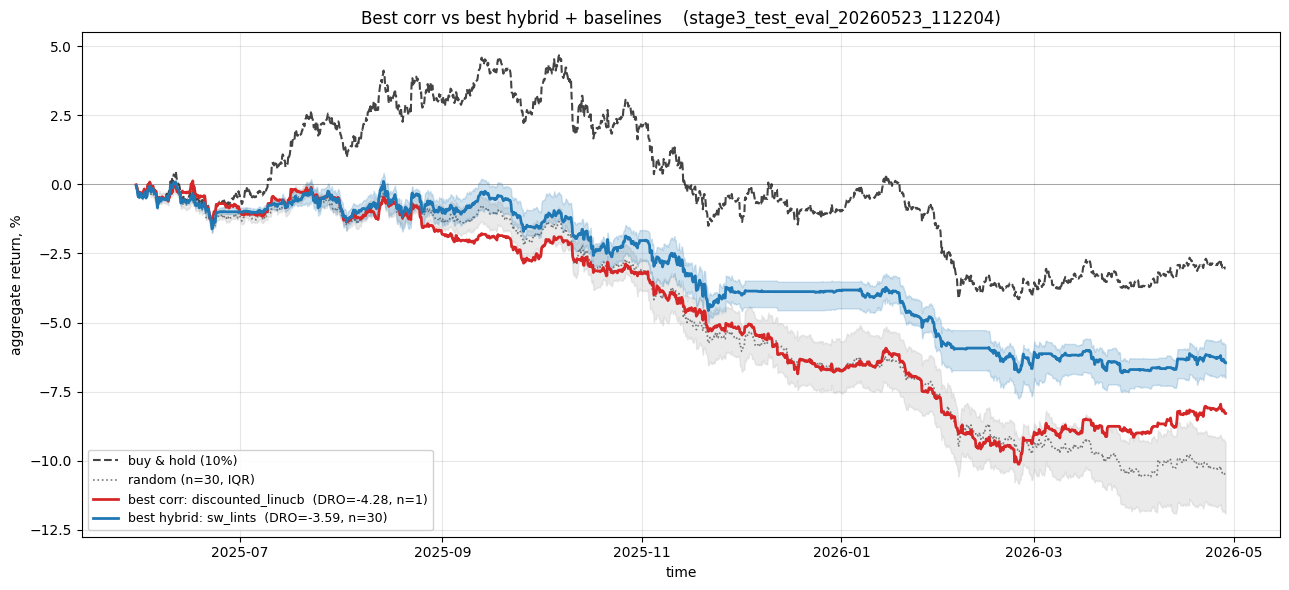

In [35]:
if EVAL_DIR_COMPARE:
    plot_best_vs_best(EVAL_DIR_COMPARE, f'  ({EVAL_DIR_COMPARE.name})')

## 10. Validation vs Test DRO — есть ли regime shift

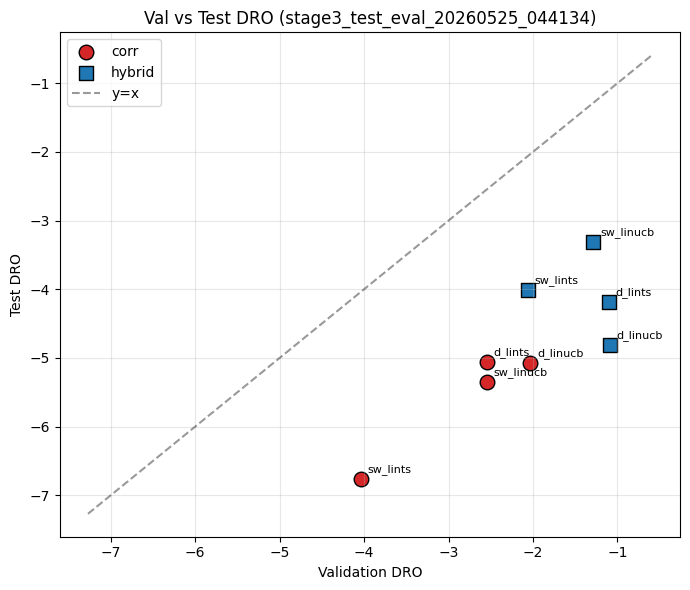

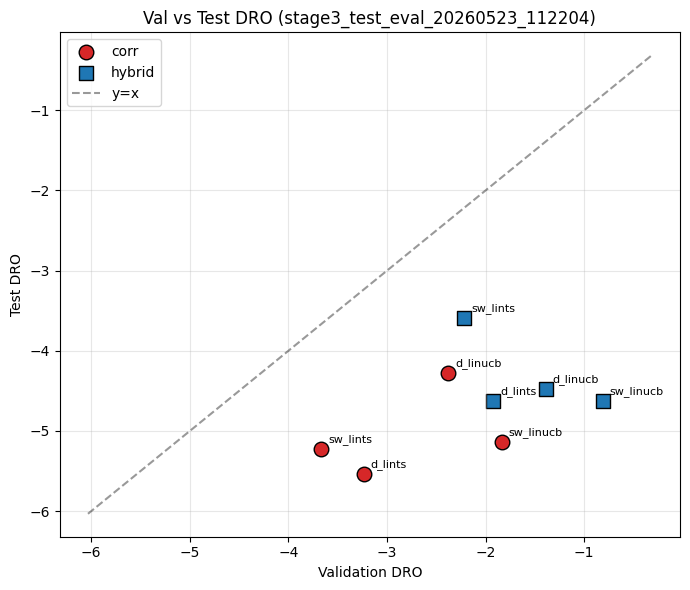

In [36]:
def plot_val_vs_test(eval_dir: Path, title_suffix: str = ''):
    df = pd.read_csv(eval_dir / 'test_optimized_config_ranking.csv')
    fig, ax = plt.subplots(figsize=(7, 6))
    for mg, marker, color in [('corr','o','#d62728'), ('hybrid','s','#1f77b4')]:
        sub = df[df['method_group'] == mg]
        ax.scatter(sub['validation_selected_dro'], sub['test_dro'], marker=marker, color=color, s=110, label=mg, edgecolor='k')
        for _, r in sub.iterrows():
            ax.annotate(r['algorithm'].replace('discounted_','d_'), (r['validation_selected_dro'], r['test_dro']),
                        fontsize=8, xytext=(5,5), textcoords='offset points')
    lo = min(df['validation_selected_dro'].min(), df['test_dro'].min()) - 0.5
    hi = max(df['validation_selected_dro'].max(), df['test_dro'].max()) + 0.5
    ax.plot([lo,hi],[lo,hi], 'k--', alpha=0.4, label='y=x')
    ax.set_xlabel('Validation DRO'); ax.set_ylabel('Test DRO')
    ax.set_title(f'Val vs Test DRO {title_suffix}'); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

plot_val_vs_test(EVAL_DIR, f'({EVAL_DIR.name})')
if EVAL_DIR_COMPARE:
    plot_val_vs_test(EVAL_DIR_COMPARE, f'({EVAL_DIR_COMPARE.name})')

## 11. Δ DRO (hybrid − corr) — bar plot

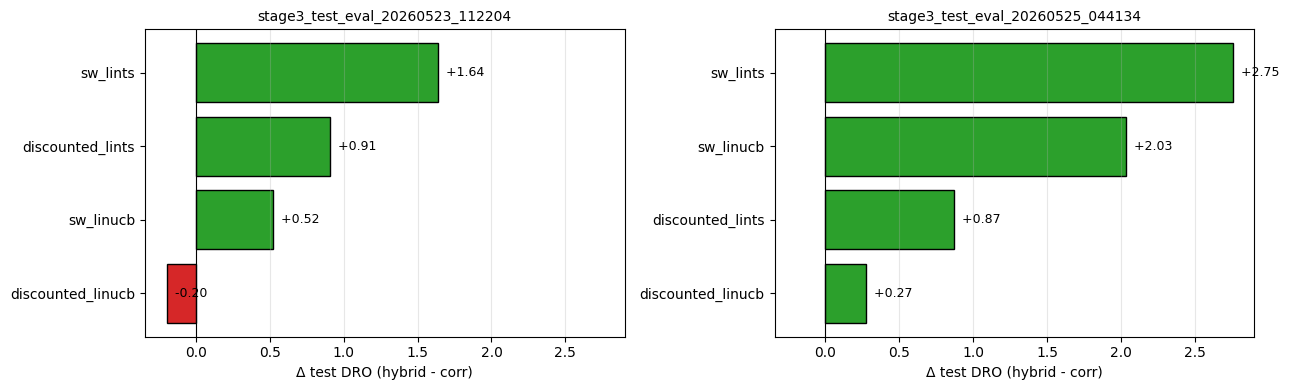

In [37]:
def plot_delta_bar(eval_dir: Path, ax, title: str):
    df = pd.read_csv(eval_dir / 'test_corr_vs_hybrid_by_algorithm.csv').sort_values('hybrid_minus_corr_dro')
    colors = ['#2ca02c' if v > 0 else '#d62728' for v in df['hybrid_minus_corr_dro']]
    ax.barh(df['algorithm'], df['hybrid_minus_corr_dro'], color=colors, edgecolor='k')
    ax.axvline(0, color='k', lw=0.8); ax.set_xlabel('Δ test DRO (hybrid - corr)')
    ax.set_title(title, fontsize=10); ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(df['hybrid_minus_corr_dro']):
        ax.text(v, i, f'  {v:+.2f}', va='center', fontsize=9)

if EVAL_DIR_COMPARE:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
    plot_delta_bar(EVAL_DIR_COMPARE, axes[0], EVAL_DIR_COMPARE.name)
    plot_delta_bar(EVAL_DIR, axes[1], EVAL_DIR.name)
else:
    fig, ax = plt.subplots(figsize=(7, 4)); plot_delta_bar(EVAL_DIR, ax, EVAL_DIR.name)
plt.tight_layout(); plt.show()

## 12. Готовые PNG-плоты (сгенерированы stage3)

**01_val_vs_test_dro_scatter.png** — `stage3_test_eval_20260525_044134`

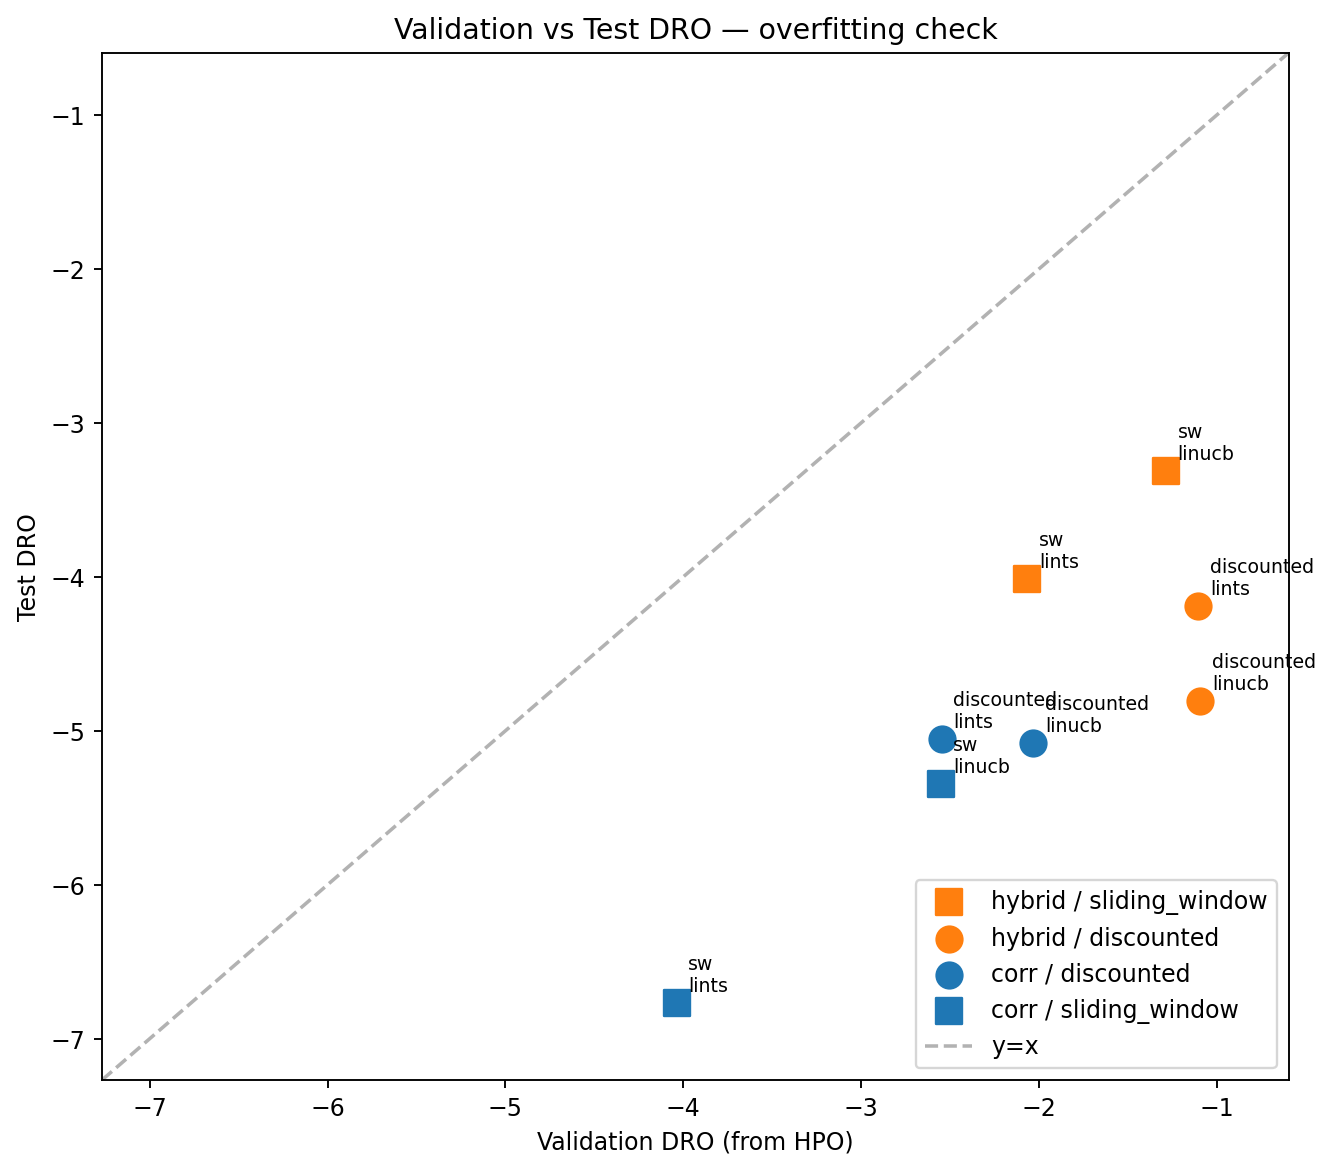

**03_hybrid_vs_corr_equity_curves.png** — `stage3_test_eval_20260525_044134`

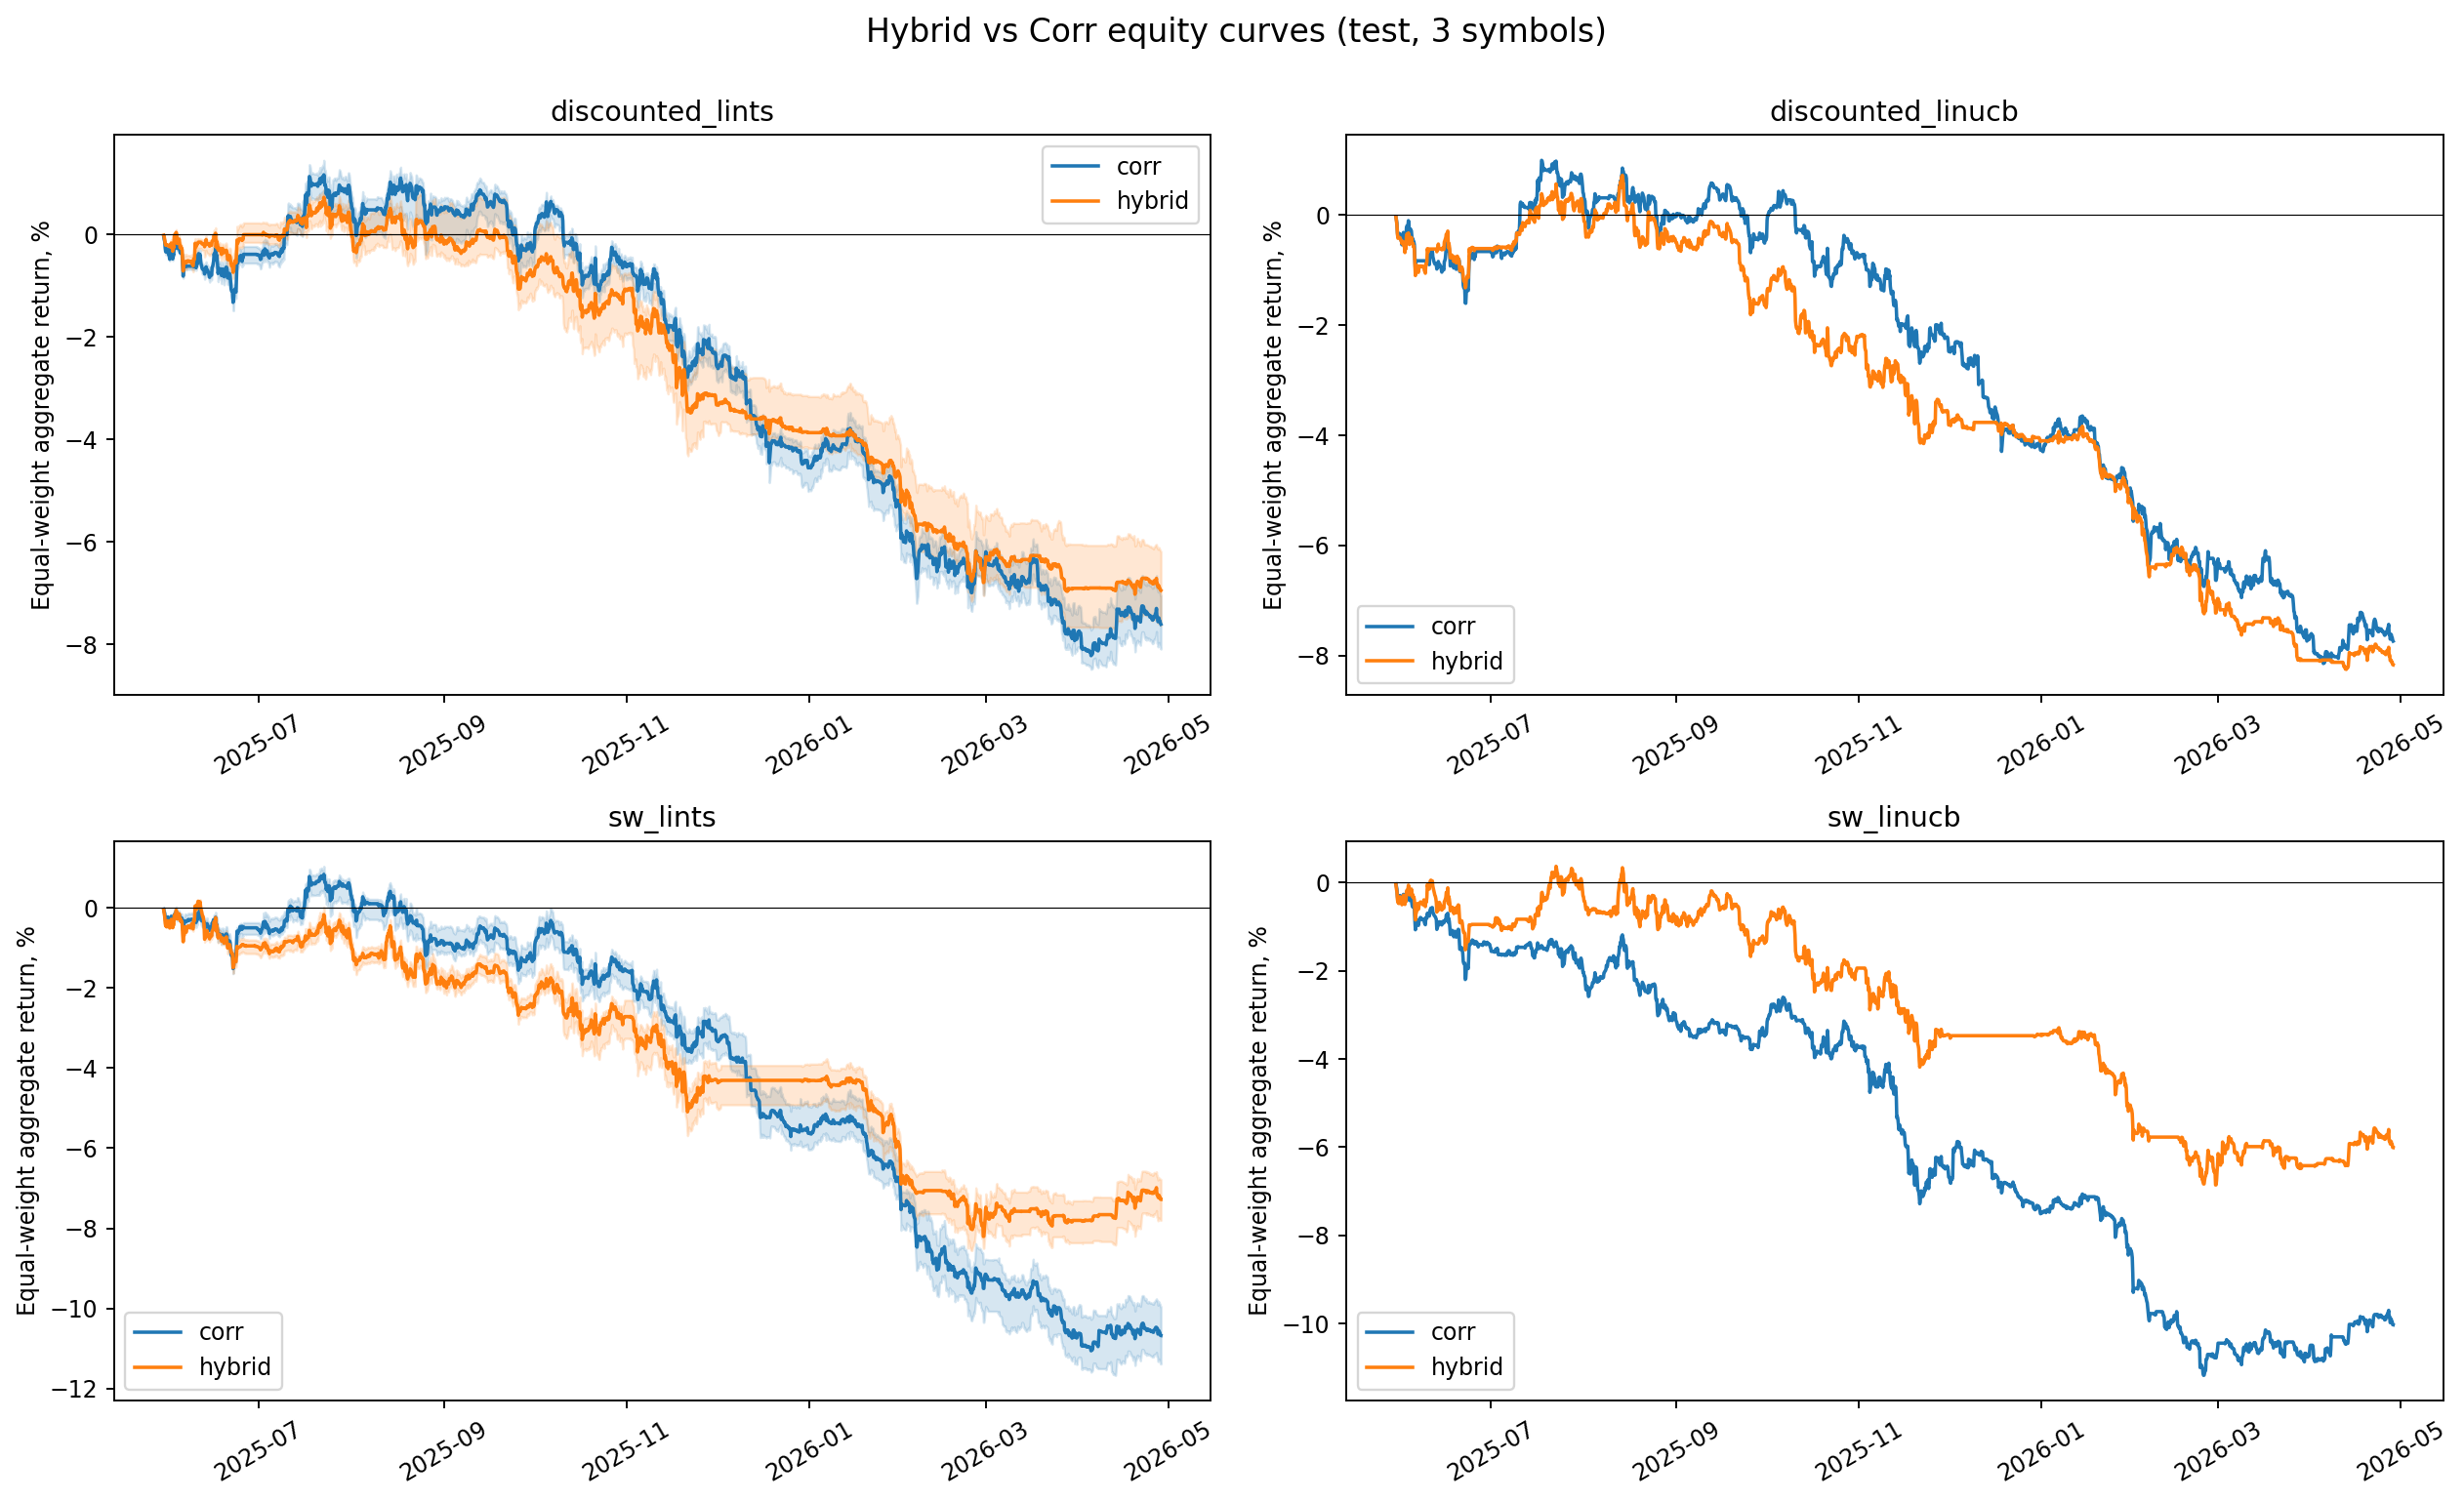

**05_per_symbol_return_heatmap.png** — `stage3_test_eval_20260525_044134`

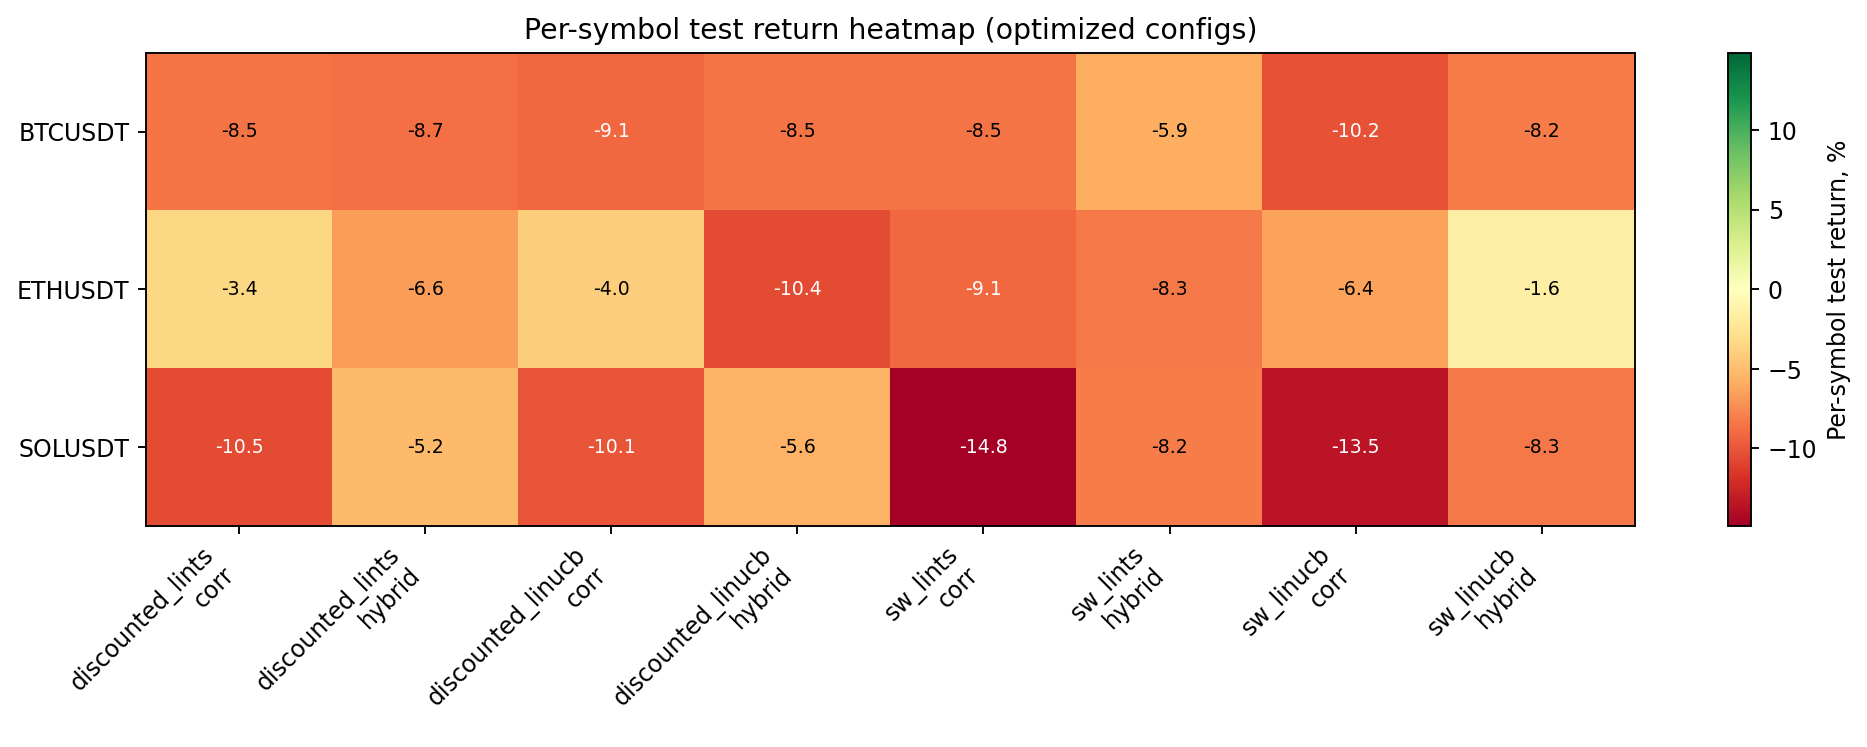

**10_bootstrap_ci_hybrid_minus_corr.png** — `stage3_test_eval_20260525_044134`

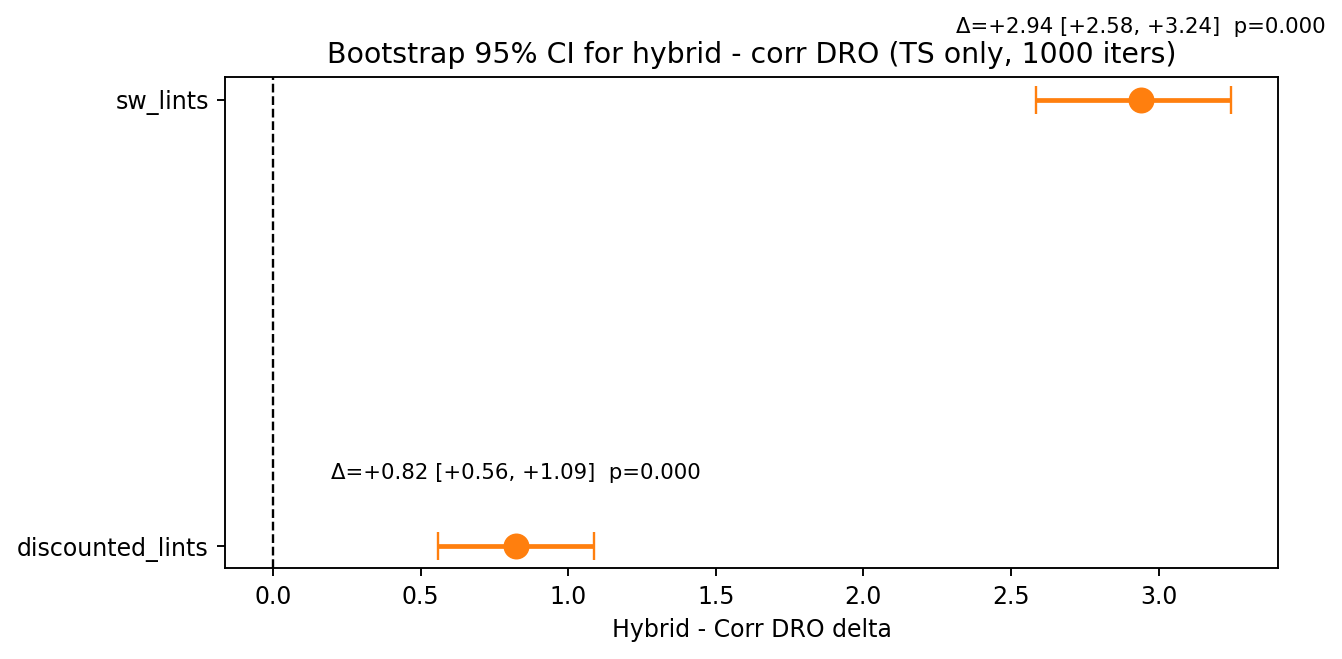

**attribution_share_hie_market.png** — `stage3_test_eval_20260525_044134`

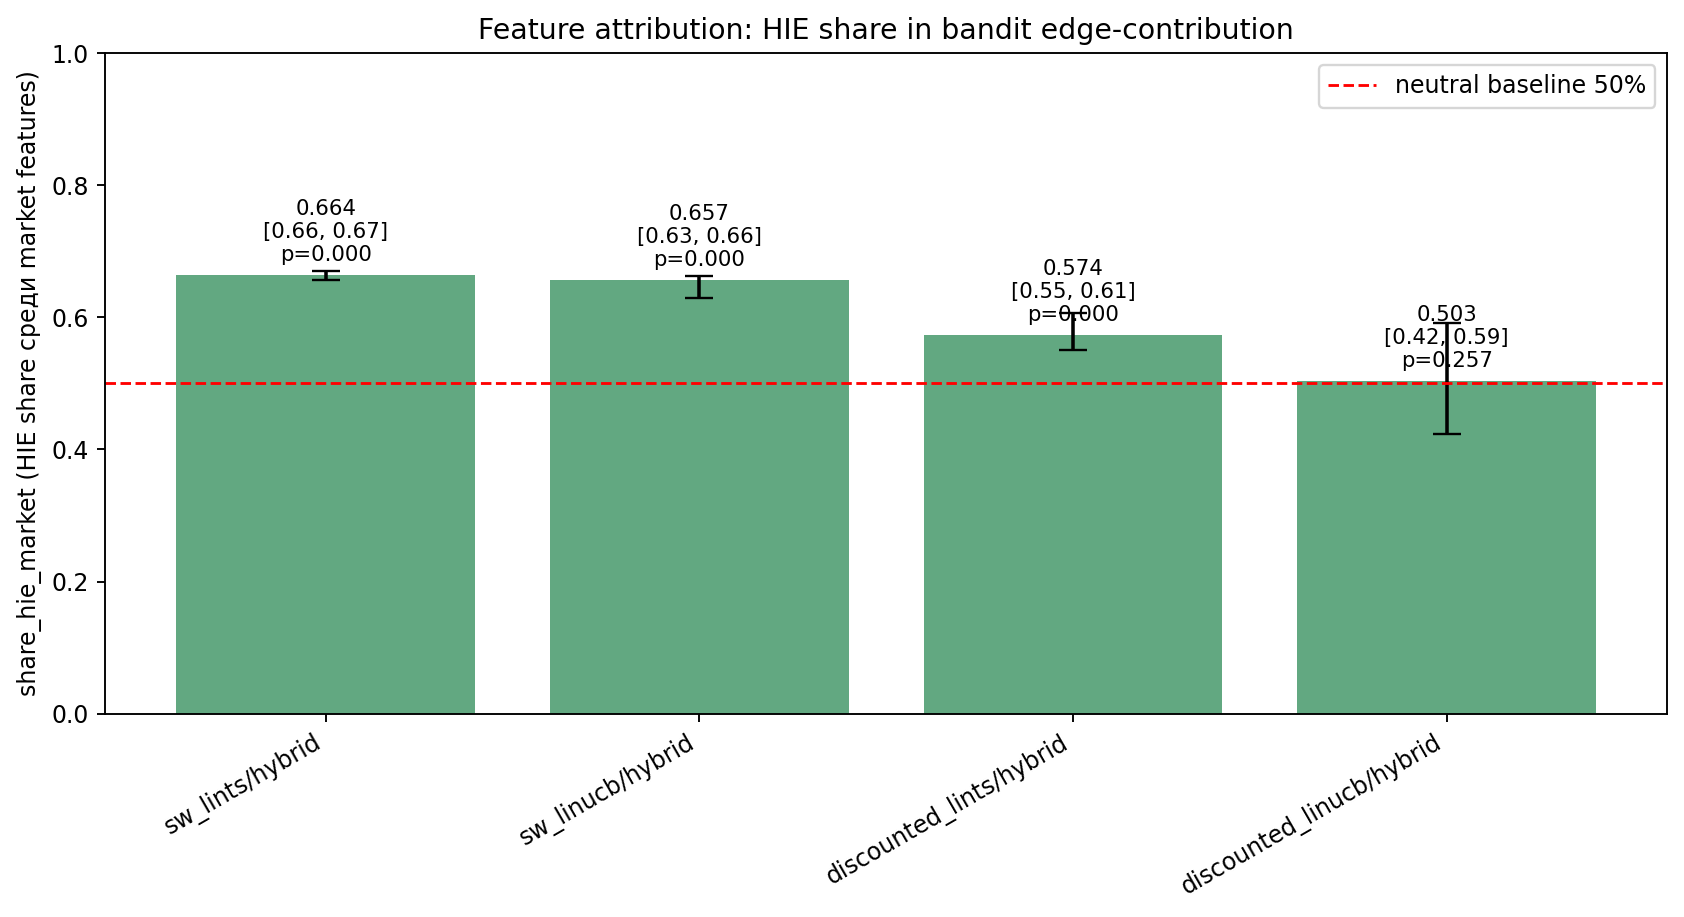

**attribution_topk_heatmap.png** — `stage3_test_eval_20260525_044134`

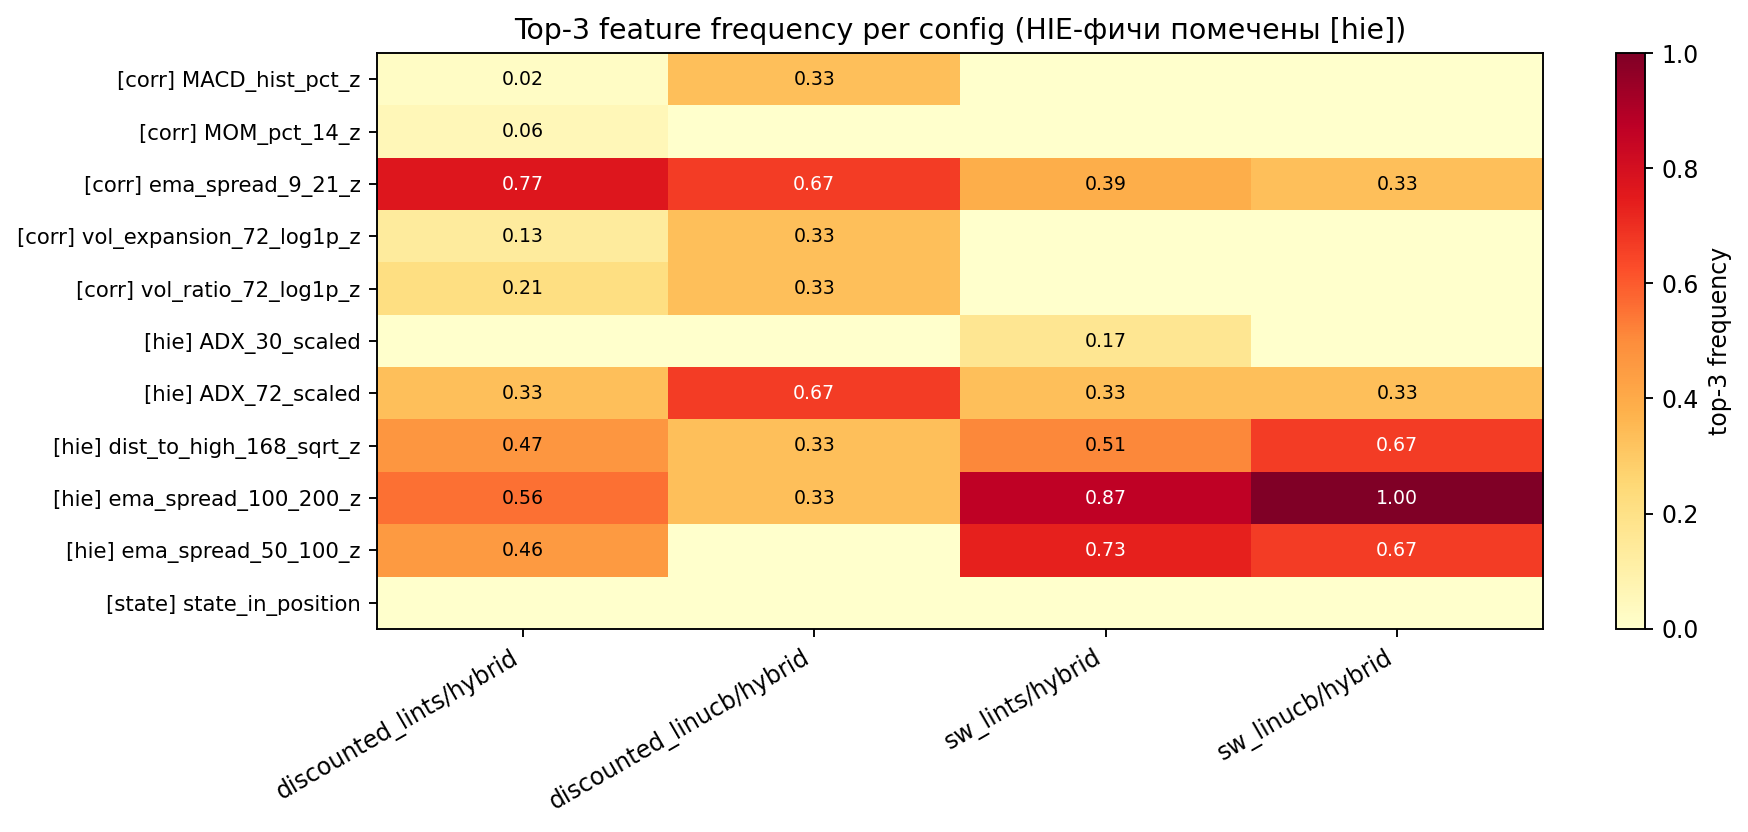

In [38]:
def show_plot(eval_dir: Path, filename: str):
    p = eval_dir / 'plots' / filename
    if not p.exists():
        print(f'НЕТ файла: {p}'); return
    display(Markdown(f'**{filename}** — `{eval_dir.name}`'))
    display(Image(filename=str(p)))

KEY_PLOTS = ['01_val_vs_test_dro_scatter.png','03_hybrid_vs_corr_equity_curves.png',
             '05_per_symbol_return_heatmap.png','10_bootstrap_ci_hybrid_minus_corr.png',
             'attribution_share_hie_market.png','attribution_topk_heatmap.png']
for fname in KEY_PLOTS:
    show_plot(EVAL_DIR, fname)

**01_val_vs_test_dro_scatter.png** — `stage3_test_eval_20260523_112204`

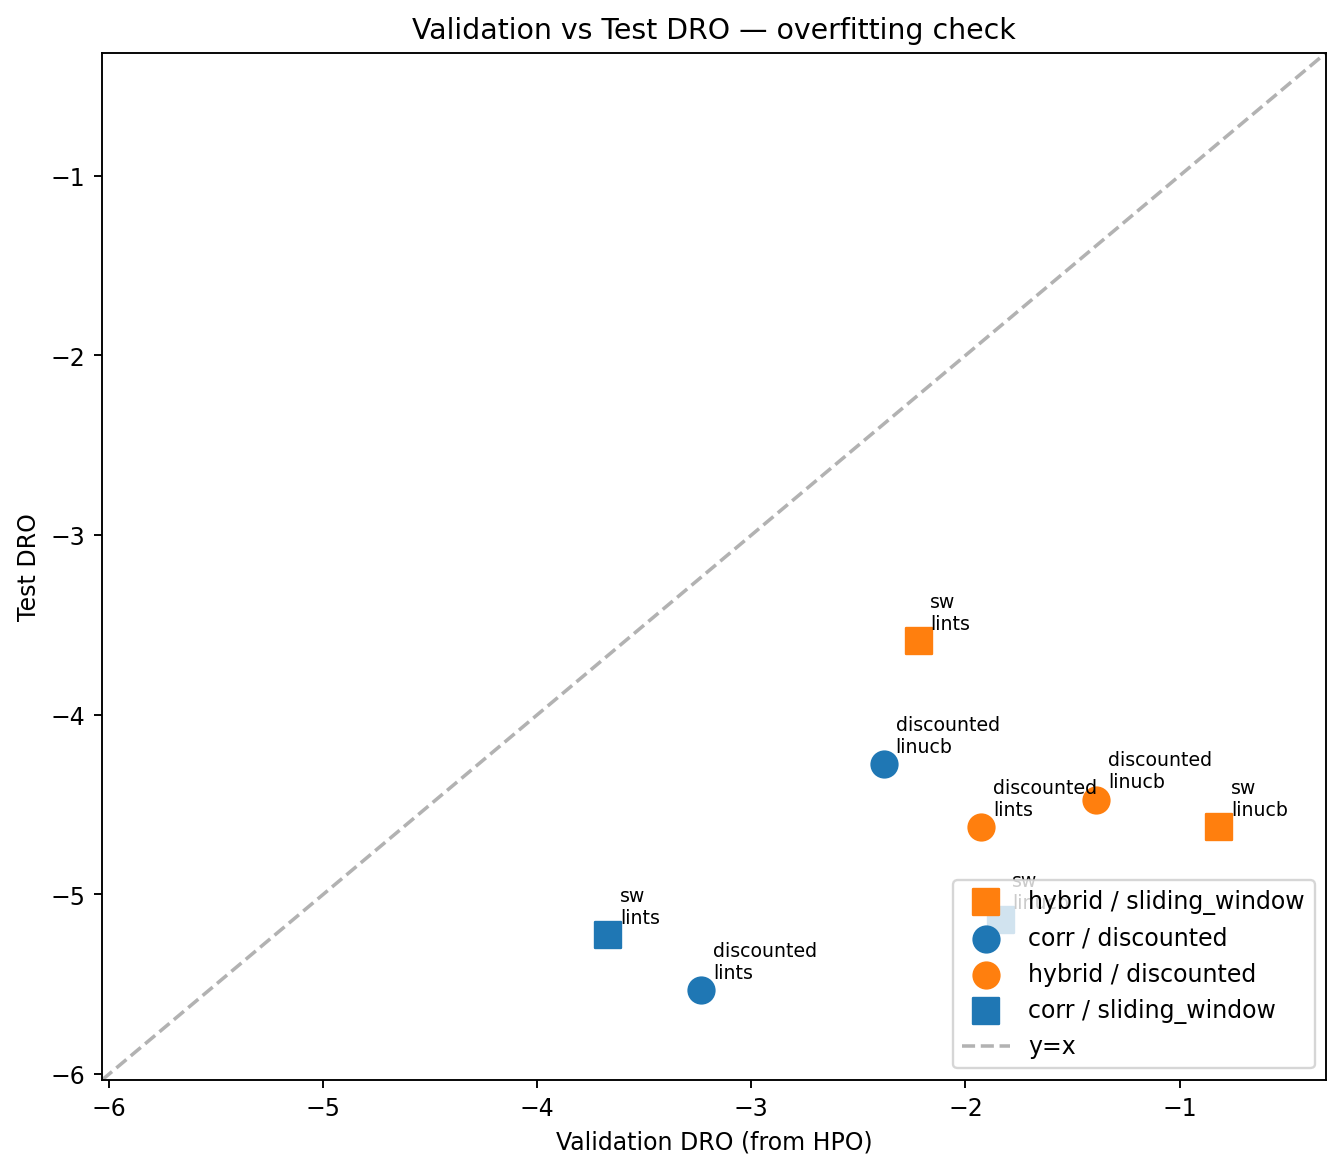

**03_hybrid_vs_corr_equity_curves.png** — `stage3_test_eval_20260523_112204`

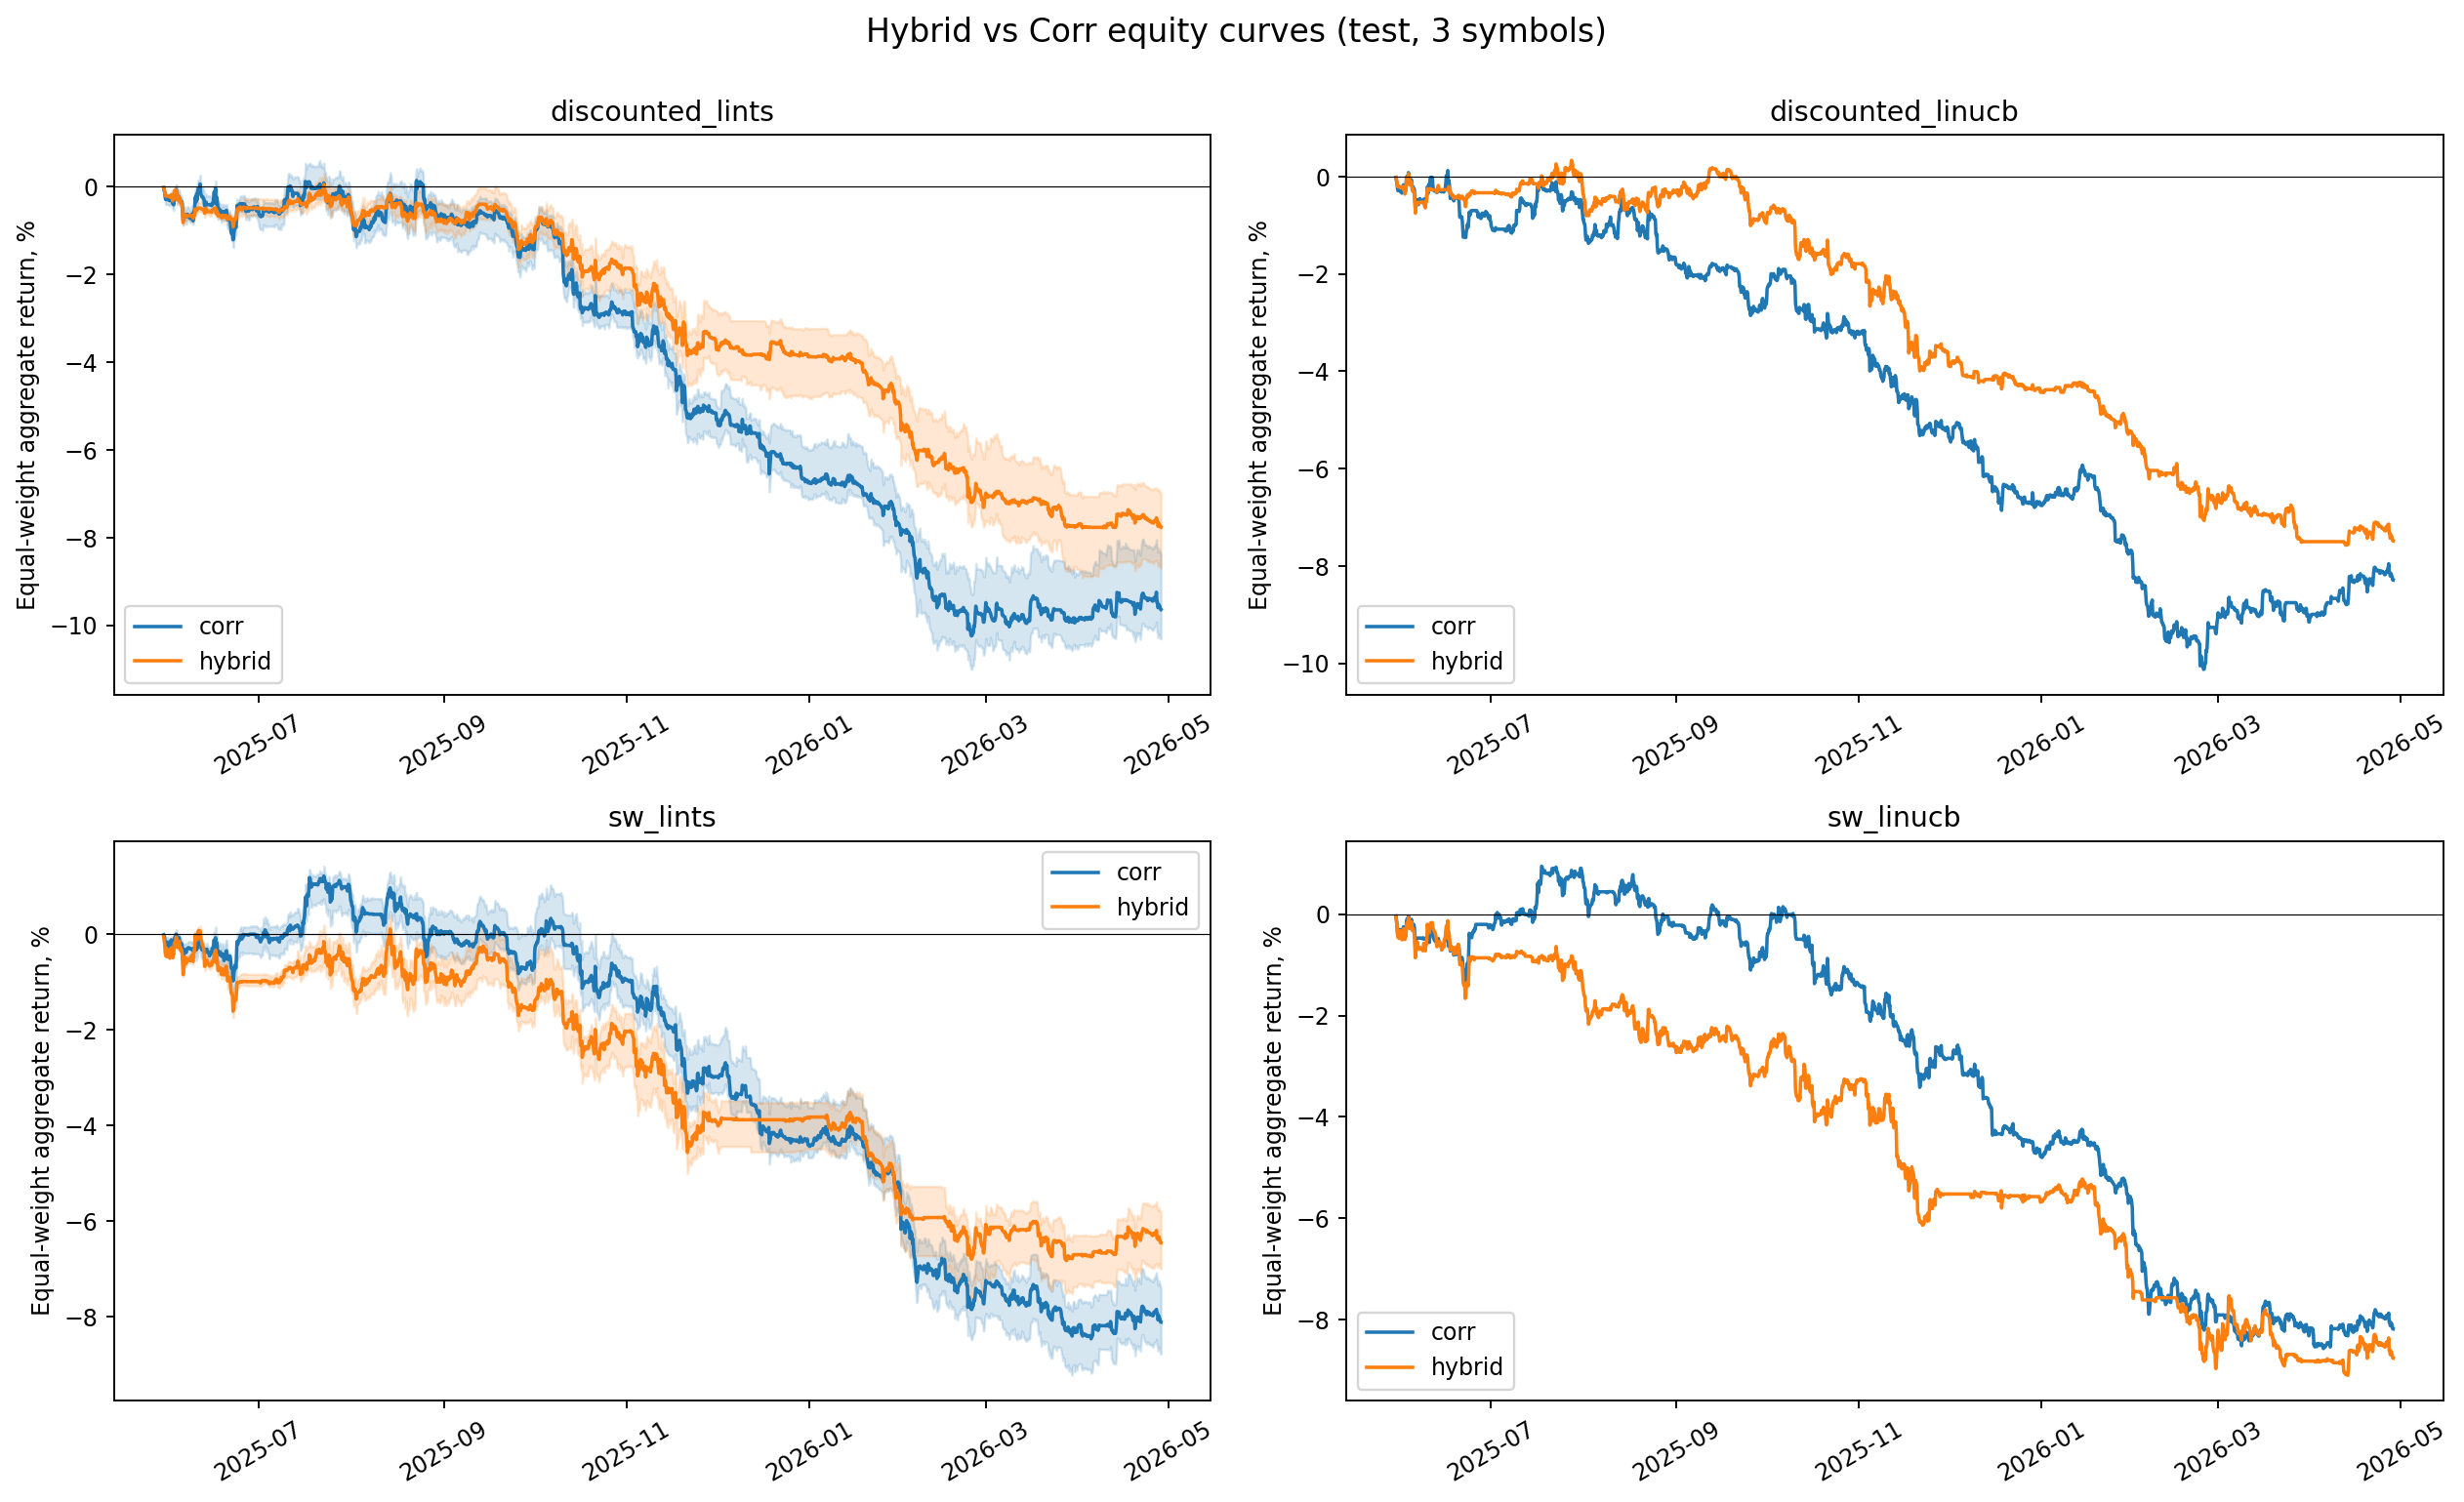

**05_per_symbol_return_heatmap.png** — `stage3_test_eval_20260523_112204`

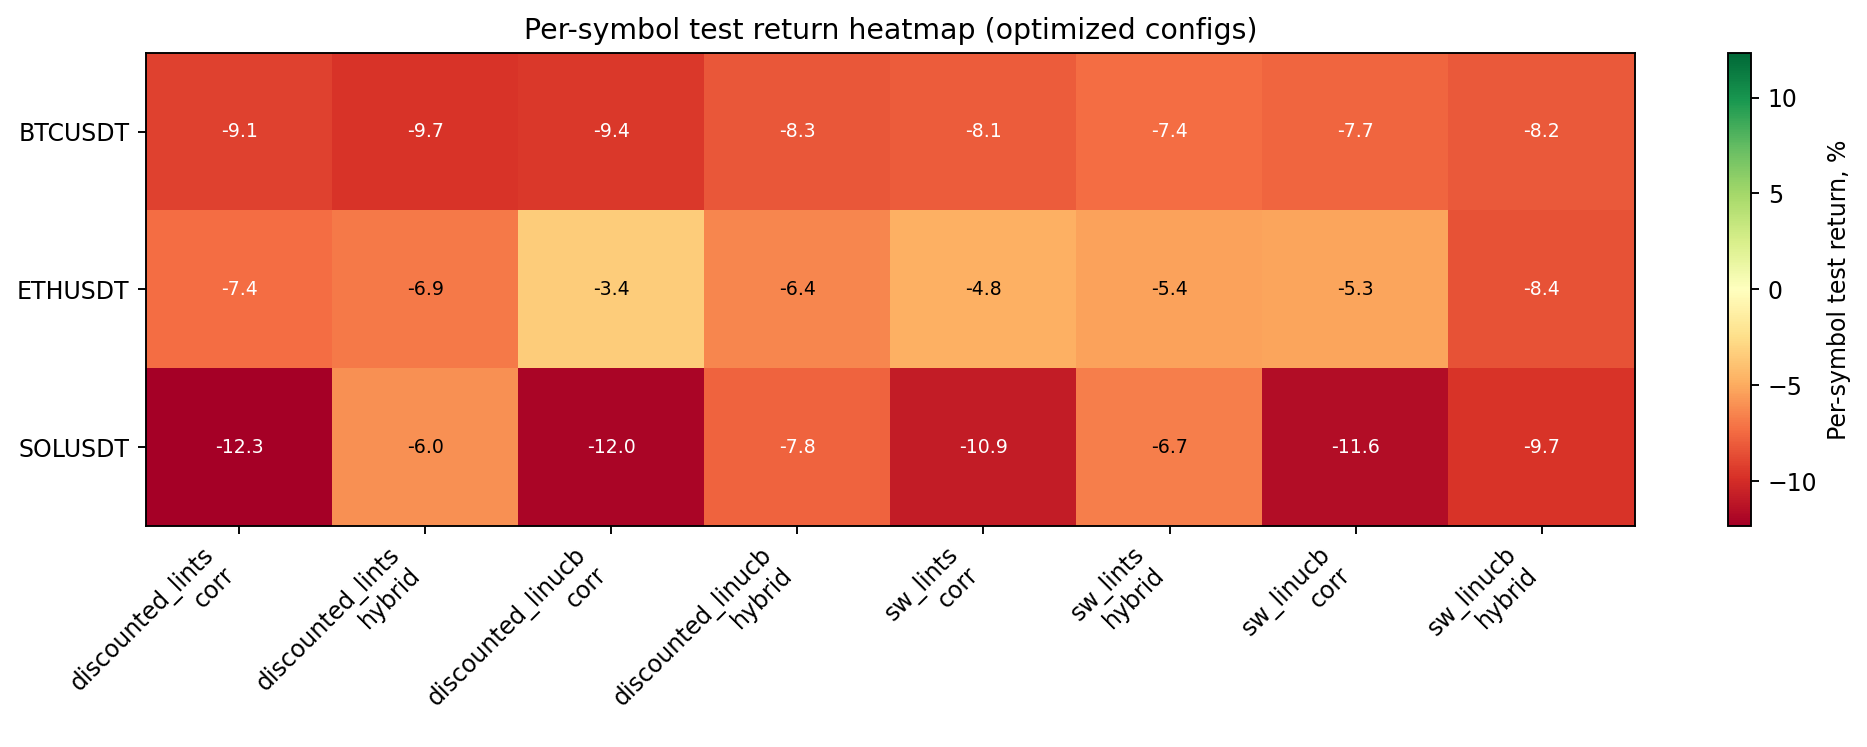

**10_bootstrap_ci_hybrid_minus_corr.png** — `stage3_test_eval_20260523_112204`

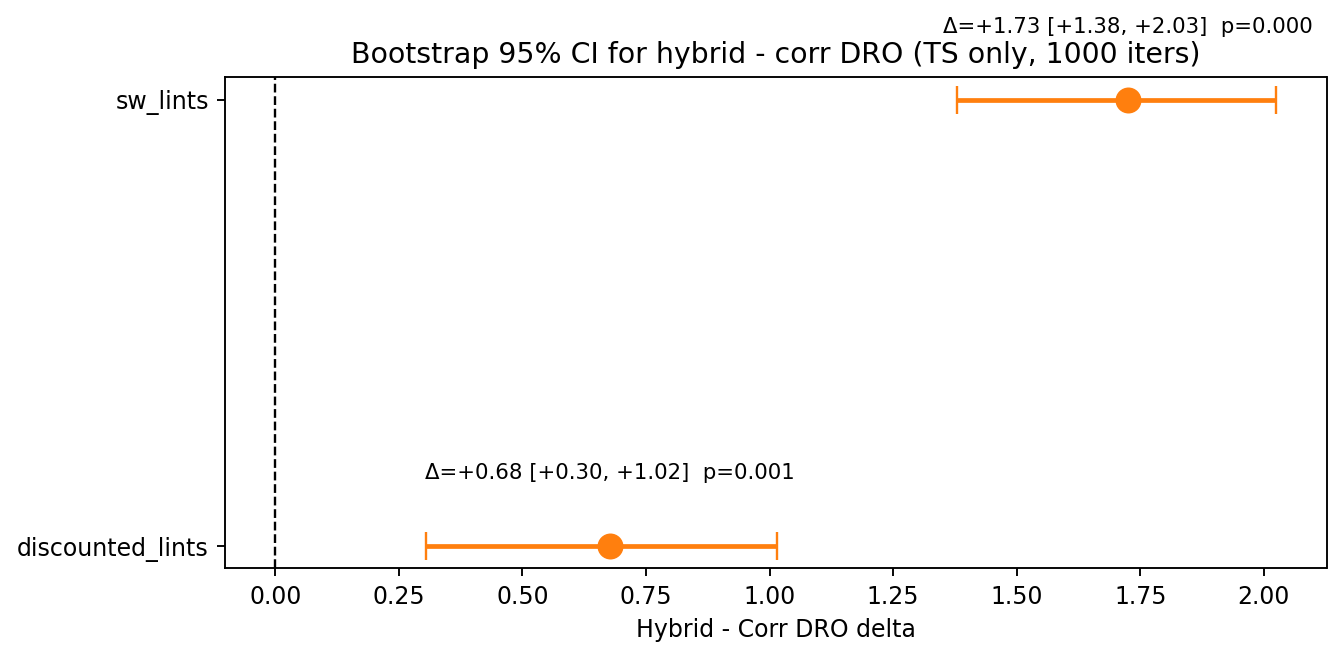

**attribution_share_hie_market.png** — `stage3_test_eval_20260523_112204`

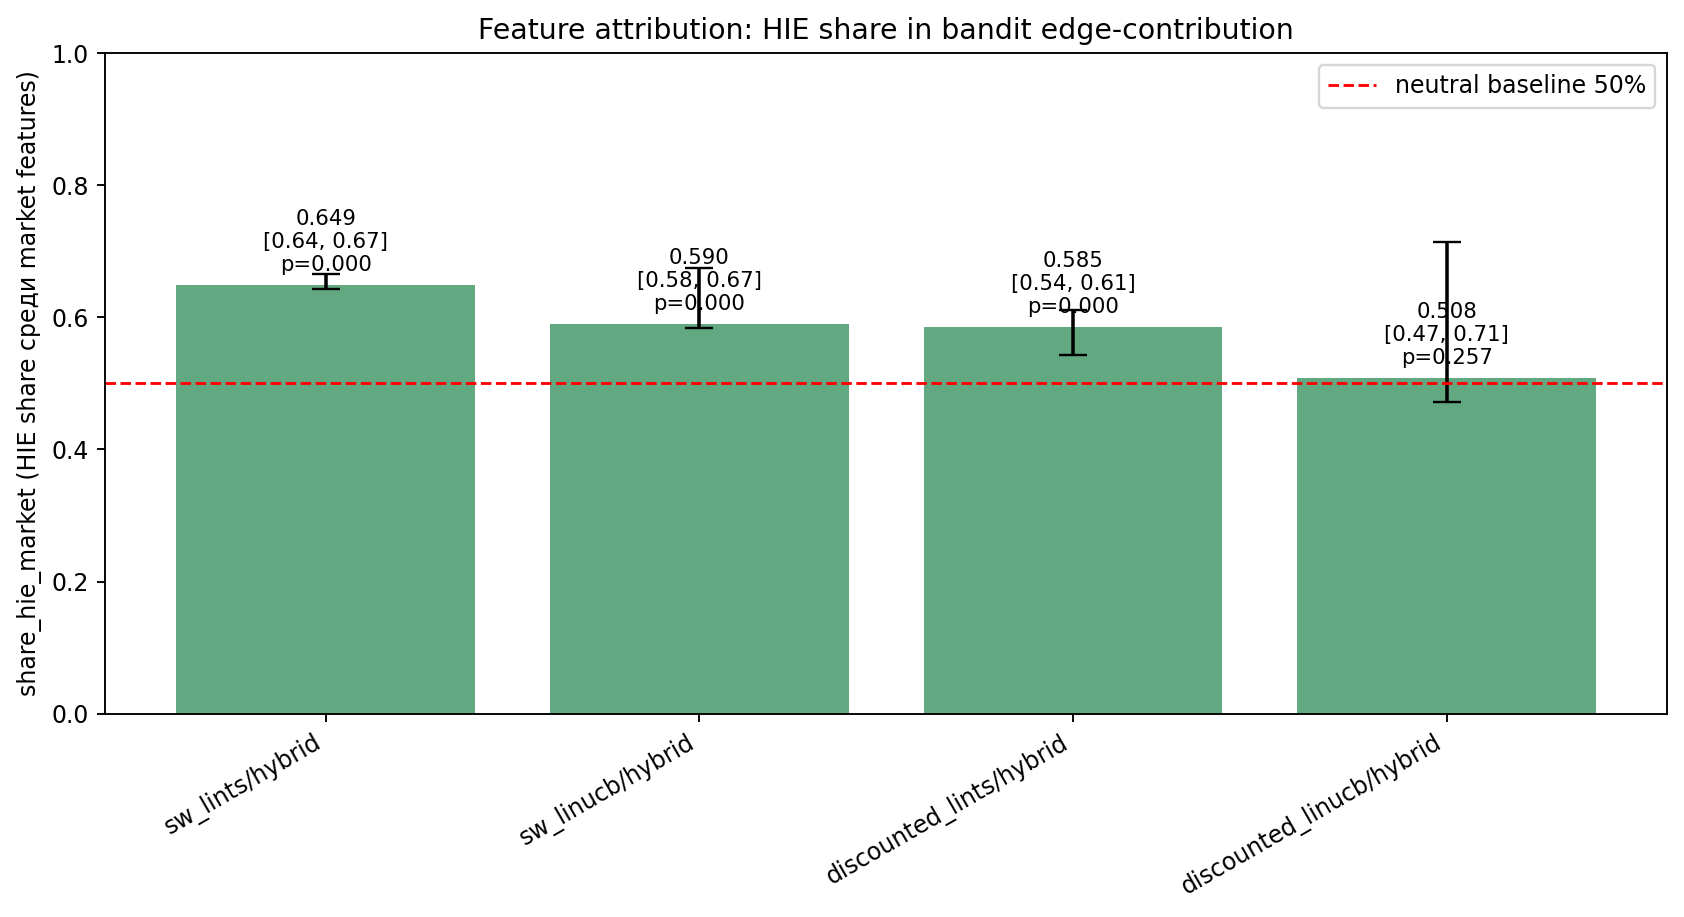

**attribution_topk_heatmap.png** — `stage3_test_eval_20260523_112204`

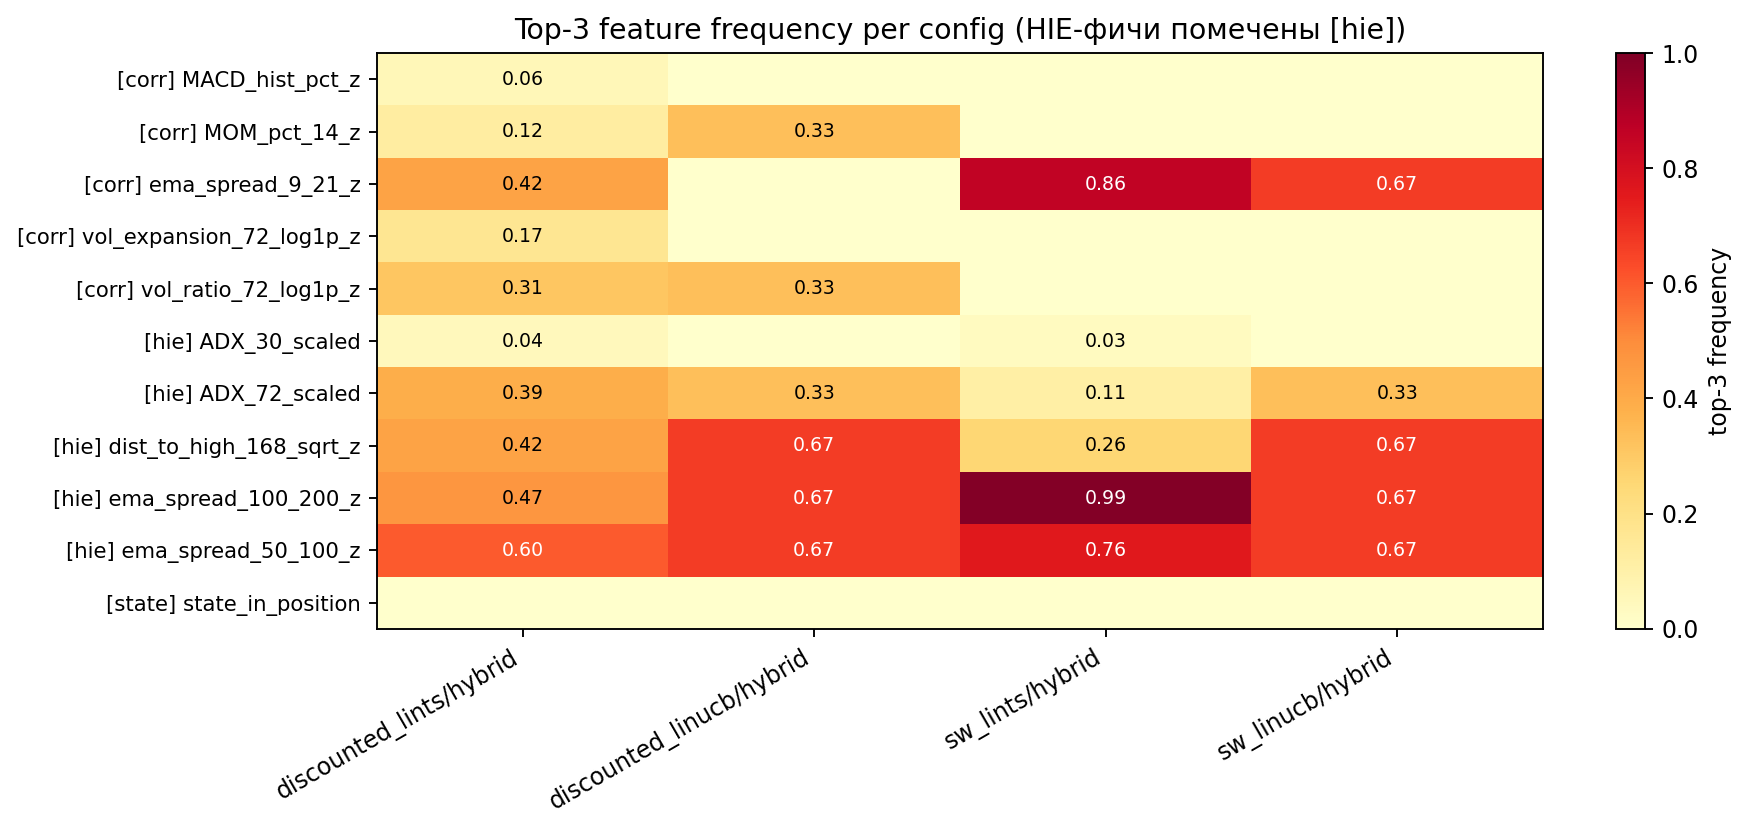

In [39]:
if EVAL_DIR_COMPARE:
    for fname in KEY_PLOTS:
        show_plot(EVAL_DIR_COMPARE, fname)

## 13. Trading behavior

**Правильная агрегация по символам:**
- `trades`, `turnover` — **SUM** по 3 символам (согласовано с `test_corr_vs_hybrid_by_algorithm.csv` → `corr_trades`, `hybrid_trades`)
- `win_rate`, `PF`, `long_ratio`, `avg_hold`, `maxDD_%` — **MEAN** по символам (rate-метрики)
- Затем медиана по 30 seeds внутри (config, метрика)

Так столбец `trades` соответствует `hybrid_trades` / `corr_trades` из таблицы Hybrid vs Corr (Section 4).

In [40]:
def trading_behavior_table(eval_dir: Path, include_baselines: bool = True) -> pd.DataFrame:
    sm = pd.read_csv(eval_dir / 'diagnostics' / 'test_symbol_metrics_all.csv')
    sm = sm[sm['mode']=='test'].copy()

    sum_cols  = ['closed_trades','turnover']
    mean_cols = ['executed_long_ratio','avg_holding_bars','win_rate','profit_factor',
                 'max_drawdown_abs','share_trades_closed_before_horizon',
                 'share_trades_closed_after_horizon','raw_executed_mismatch_ratio',
                 'forced_singleton_ratio']
    sum_cols  = [c for c in sum_cols  if c in sm.columns]
    mean_cols = [c for c in mean_cols if c in sm.columns]

    group_cols = ['config_id','config_type','algorithm','method_group','seed']
    agg_dict = {c: 'sum' for c in sum_cols}
    agg_dict.update({c: 'mean' for c in mean_cols})
    by_seed = sm.groupby(group_cols).agg(agg_dict).reset_index()

    cfg_cols = ['config_id','config_type','algorithm','method_group']
    metric_cols = sum_cols + mean_cols
    by_cfg = by_seed.groupby(cfg_cols)[metric_cols].median().reset_index()

    keep = ['optimized'] + (['baseline'] if include_baselines else [])
    by_cfg = by_cfg[by_cfg['config_type'].isin(keep)].copy()
    by_cfg['_order'] = by_cfg['config_type'].map({'optimized':0,'baseline':1})
    by_cfg = by_cfg.sort_values(['_order','algorithm','method_group']).drop(columns='_order')

    out = pd.DataFrame({
        'config':        by_cfg['config_id'].str.replace('optimized__','').str.replace('baseline__','BL: '),
        'trades':        by_cfg['closed_trades'].round(0).astype('Int64'),
        'turnover':      by_cfg['turnover'].round(3),
        'long_ratio':    by_cfg['executed_long_ratio'].round(3),
        'avg_hold':      by_cfg['avg_holding_bars'].round(2),
        'win_rate':      by_cfg['win_rate'].round(3),
        'PF':            by_cfg['profit_factor'].round(3),
        'maxDD_%':       by_cfg['max_drawdown_abs'].round(2),
    })
    if 'share_trades_closed_before_horizon' in by_cfg.columns:
        out['pct_lt_H'] = by_cfg['share_trades_closed_before_horizon'].round(3)
    if 'share_trades_closed_after_horizon' in by_cfg.columns:
        out['pct_ge_H'] = by_cfg['share_trades_closed_after_horizon'].round(3)
    if 'raw_executed_mismatch_ratio' in by_cfg.columns:
        out['raw_neq_ex'] = by_cfg['raw_executed_mismatch_ratio'].round(3)
    if 'forced_singleton_ratio' in by_cfg.columns:
        out['forced_sgl'] = by_cfg['forced_singleton_ratio'].round(3)
    return out.reset_index(drop=True)

display(Markdown(f'### Trading behavior — `{EVAL_DIR.name}`'))
display(trading_behavior_table(EVAL_DIR, include_baselines=True))

### Trading behavior — `stage3_test_eval_20260525_044134`

,config,trades,turnover,long_ratio,avg_hold,win_rate,PF,maxDD_%,pct_lt_H,pct_ge_H,raw_neq_ex,forced_sgl
0,discounted_lints__corr,488,0.4900,0.5560,6.9700,0.4100,0.6180,9.6400,0.8330,0.1670,0.1730,0.3270
1,discounted_lints__hybrid,385,0.3860,0.3890,6.2300,0.4080,0.5450,8.5500,0.8840,0.1160,0.1770,0.2570
2,discounted_linucb__corr,499,0.5000,0.5470,6.8300,0.3980,0.6070,9.5200,0.8490,0.1510,0.1890,0.3330
3,discounted_linucb__hybrid,424,0.4240,0.4440,6.3600,0.4170,0.5390,9.7300,0.8830,0.1170,0.1910,0.2830
4,sw_lints__corr,508,0.5090,0.5330,6.3100,0.3780,0.5240,12.1300,0.8640,0.1360,0.2050,0.3400
5,sw_lints__hybrid,274,0.2740,0.5020,11.2400,0.4210,0.5030,8.7900,0.7410,0.2590,0.1130,0.1830
6,sw_linucb__corr,413,0.4140,0.5580,8.0500,0.3750,0.4960,11.9300,0.7750,0.2250,0.1500,0.2770
7,sw_linucb__hybrid,285,0.2860,0.5440,11.4400,0.4350,0.5840,7.9700,0.7440,0.2560,0.1160,0.1900
8,BL: buy_hold_entry_cost_full_capital,0,0.0020,1.0000,2000.00,NaN,NaN,60.4000,0.0000,1.0000,NaN,NaN
9,BL: buy_hold_entry_cost_position_size,0,0.0020,1.0000,2000.00,NaN,NaN,8.7400,0.0000,1.0000,NaN,NaN


In [41]:
if EVAL_DIR_COMPARE:
    display(Markdown(f'### Trading behavior — `{EVAL_DIR_COMPARE.name}`'))
    display(trading_behavior_table(EVAL_DIR_COMPARE, include_baselines=True))

### Trading behavior — `stage3_test_eval_20260523_112204`

,config,trades,turnover,long_ratio,avg_hold,win_rate,PF,maxDD_%,pct_lt_H,pct_ge_H,raw_neq_ex,forced_sgl
0,discounted_lints__corr,550,0.5520,0.5130,5.6500,0.3900,0.5780,11.4000,0.9040,0.0960,0.0000,0.3680
1,discounted_lints__hybrid,408,0.4080,0.3910,5.5900,0.4020,0.5290,8.9000,0.9270,0.0730,0.0000,0.2720
2,discounted_linucb__corr,557,0.5580,0.5200,5.6500,0.4180,0.6210,10.4000,0.8960,0.1040,0.0000,0.3730
3,discounted_linucb__hybrid,432,0.4340,0.3850,5.4000,0.3880,0.5420,8.6800,0.9300,0.0700,0.0000,0.2890
4,sw_lints__corr,452,0.4530,0.5180,6.9000,0.3990,0.5840,10.2200,0.8270,0.1730,0.0000,0.3020
5,sw_lints__hybrid,270,0.2710,0.5110,11.4700,0.4330,0.5370,8.1200,0.7240,0.2760,0.0000,0.1810
6,sw_linucb__corr,526,0.5270,0.5280,6.0600,0.4000,0.6040,10.1100,0.8620,0.1380,0.0000,0.3510
7,sw_linucb__hybrid,392,0.3930,0.5370,8.1500,0.4000,0.5420,9.5000,0.8140,0.1860,0.0000,0.2630
8,BL: buy_hold_entry_cost_full_capital,0,0.0020,1.0000,2000.00,NaN,NaN,60.4000,0.0000,1.0000,NaN,NaN
9,BL: buy_hold_entry_cost_position_size,0,0.0020,1.0000,2000.00,NaN,NaN,8.7400,0.0000,1.0000,NaN,NaN


In [42]:
def behavior_gap_hybrid_vs_corr(eval_dir: Path) -> pd.DataFrame:
    tb = trading_behavior_table(eval_dir, include_baselines=False).copy()
    parsed = tb['config'].str.split('__', expand=True)
    tb['algo'] = parsed[0]; tb['method'] = parsed[1]
    metrics = ['trades','avg_hold','long_ratio','win_rate','PF','maxDD_%','turnover']
    rows = []
    for alg in sorted(tb['algo'].unique()):
        c = tb[(tb['algo']==alg) & (tb['method']=='corr')]
        h = tb[(tb['algo']==alg) & (tb['method']=='hybrid')]
        if c.empty or h.empty: continue
        row = {'algorithm': alg}
        for m in metrics:
            row[f'{m} (corr)']   = c.iloc[0][m]
            row[f'{m} (hybrid)'] = h.iloc[0][m]
        rows.append(row)
    return pd.DataFrame(rows)

display(Markdown(f'### Hybrid vs Corr — поведение бок о бок — `{EVAL_DIR.name}`'))
display(behavior_gap_hybrid_vs_corr(EVAL_DIR))

### Hybrid vs Corr — поведение бок о бок — `stage3_test_eval_20260525_044134`

,algorithm,trades (corr),trades (hybrid),avg_hold (corr),avg_hold (hybrid),long_ratio (corr),long_ratio (hybrid),win_rate (corr),win_rate (hybrid),PF (corr),PF (hybrid),maxDD_% (corr),maxDD_% (hybrid),turnover (corr),turnover (hybrid)
0,discounted_lints,488,385,6.9700,6.2300,0.5560,0.3890,0.4100,0.4080,0.6180,0.5450,9.6400,8.5500,0.4900,0.3860
1,discounted_linucb,499,424,6.8300,6.3600,0.5470,0.4440,0.3980,0.4170,0.6070,0.5390,9.5200,9.7300,0.5000,0.4240
2,sw_lints,508,274,6.3100,11.2400,0.5330,0.5020,0.3780,0.4210,0.5240,0.5030,12.1300,8.7900,0.5090,0.2740
3,sw_linucb,413,285,8.0500,11.4400,0.5580,0.5440,0.3750,0.4350,0.4960,0.5840,11.9300,7.9700,0.4140,0.2860


## 14. Дополнительные плоты

In [43]:
EXTRA_PLOTS = ['02_hpo_impact_default_vs_optimized.png','04_selected_equity_curves.png',
               '06_ts_seed_variance_boxplots.png','07_return_vs_drawdown_scatter.png',
               '08_holding_time_distribution.png','09_h1_vs_h2_returns.png',
               '11_decision_only_diagnostics.png','12_calmar_ranking.png']
# for fname in EXTRA_PLOTS: show_plot(EVAL_DIR, fname)
print('Раскомментируйте для просмотра')

Раскомментируйте для просмотра


## 15. Список файлов в папке

In [44]:
print(f'=== {EVAL_DIR.name} ===')
for p in sorted(EVAL_DIR.iterdir()):
    if p.is_file():
        print(f'  {p.name}  ({p.stat().st_size // 1024} KB)')
    else:
        print(f'  {p.name}/')
        for q in sorted(p.iterdir())[:25]:
            print(f'    {q.name}')

=== stage3_test_eval_20260525_044134 ===
  diagnostics/
    test_aggregate_equity_curves.csv
    test_split_summary_used.csv
    test_symbol_metrics_all.csv
  feature_attribution_per_feature.csv  (384 KB)
  feature_attribution_share_per_seed.csv  (36 KB)
  feature_attribution_share_summary.csv  (0 KB)
  feature_attribution_topk_long.csv  (223 KB)
  feature_attribution_topk_summary.csv  (5 KB)
  final_test_configurations.csv  (7 KB)
  plots/
    01_val_vs_test_dro_scatter.png
    02_hpo_impact_default_vs_optimized.png
    03_hybrid_vs_corr_equity_curves.png
    04_selected_equity_curves.png
    05_per_symbol_return_heatmap.png
    06_ts_seed_variance_boxplots.png
    07_return_vs_drawdown_scatter.png
    08_holding_time_distribution.png
    09_h1_vs_h2_returns.png
    10_bootstrap_ci_hybrid_minus_corr.png
    11_decision_only_diagnostics.png
    12_calmar_ranking.png
    attribution_share_hie_market.png
    attribution_topk_heatmap.png
  test_bootstrap_hybrid_minus_corr_ci.csv  (0 KB)
 